In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd

from transaction_analysis.config.paths import FRAUD_DATASET_DIR

## 1. Fraud Transactions - Analiza zbioru danych do profilowania oszustw 
W niniejszej prezentacji przedstawiono pełną analizę zbioru do identyfikacji wzorców i cech charakterystycznych dla transakcji oszukańczych.

Analiza tego typu danych jest kluczowa dla skutecznego wykrywania nadużyć finansowych, ograniczania strat oraz zwiększania bezpieczeństwa systemów płatniczych i ich użytkowników.

## 2. Analiza zbioru
Surowy zbiór danych składa się z następujących plików:
```
1. cards_data.csv
2. transactions_data.csv
3. users_data.csv
4. mcc_codes.json
5. train_fraud_labels.json
```

Analiza zbioru pozwoliła nam stwierdzić, że przed przystąpieniem do EDA oraz modelowania potrzebne będzie zoptymalizowanie danych.

Dodatkowo, taki podział zbioru danych wymaga dodatkowych kroków związanych z optymalnym łączeniem tabel.

## 3. Preprocessing danych

Optymalizacja reprezentacji tabel, dobranie właściwych typów danych.

Zawartość kolumn *na razie* nie jest zmieniana

In [4]:
cards = pd.read_csv(FRAUD_DATASET_DIR / "raw" / "cards_data.csv")
users = pd.read_csv(FRAUD_DATASET_DIR / "raw" / "users_data.csv")
cards.info()
print()
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     6146 non-null   int64
 1   client_id              6146 non-null   int64
 2   card_brand             6146 non-null   str  
 3   card_type              6146 non-null   str  
 4   card_number            6146 non-null   int64
 5   expires                6146 non-null   str  
 6   cvv                    6146 non-null   int64
 7   has_chip               6146 non-null   str  
 8   num_cards_issued       6146 non-null   int64
 9   credit_limit           6146 non-null   str  
 10  acct_open_date         6146 non-null   str  
 11  year_pin_last_changed  6146 non-null   int64
 12  card_on_dark_web       6146 non-null   str  
dtypes: int64(6), str(7)
memory usage: 851.5 KB

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Colu

In [5]:
transactions = pd.read_csv(FRAUD_DATASET_DIR / "raw" / "transactions_data.csv")
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            str    
 2   client_id       int64  
 3   card_id         int64  
 4   amount          str    
 5   use_chip        str    
 6   merchant_id     int64  
 7   merchant_city   str    
 8   merchant_state  str    
 9   zip             float64
 10  mcc             int64  
 11  errors          str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.8 GB


Aby móc komfortowo pracować z dużym zbiorem danych, należy dobrać odpowiednie typy danych dla kolumn:

- Liczby całkowitoliczbowe zostali zrzutowane na najmniejszy typ, który może je przechować
- Powtarzające się ciągi znakowe `str` zrzutowano na kategorie
- Daty zrzutowano na `datetime`
- Kolumny składające z `True`, `False` zrzutowano na `bool`

In [6]:
# del cards, users, transactions

# import transaction_analysis.data.step.preprocess as preprocess

# preprocess.run(FRAUD_DATASET_DIR / "raw", FRAUD_DATASET_DIR / "preprocessed")

cards = pd.read_parquet(FRAUD_DATASET_DIR / "preprocessed" / "cards.parquet")
users = pd.read_parquet(FRAUD_DATASET_DIR / "preprocessed" / "users.parquet")
cards.info()
print()
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   uint16        
 1   client_id              6146 non-null   uint16        
 2   card_brand             6146 non-null   category      
 3   card_type              6146 non-null   category      
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[us]
 6   cvv                    6146 non-null   uint16        
 7   has_chip               6146 non-null   boolean       
 8   num_cards_issued       6146 non-null   uint8         
 9   credit_limit           6146 non-null   float32       
 10  acct_open_date         6146 non-null   datetime64[us]
 11  year_pin_last_changed  6146 non-null   uint16        
 12  card_on_dark_web       6146 non-null   boolean       
dtypes: boolean(2),

In [7]:
transactions = pd.read_parquet(FRAUD_DATASET_DIR / "preprocessed" / "transactions.parquet")
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              uint32        
 1   date            datetime64[us]
 2   client_id       uint16        
 3   card_id         uint16        
 4   amount          float32       
 5   use_chip        category      
 6   merchant_id     uint32        
 7   merchant_city   category      
 8   merchant_state  category      
 9   zip             category      
 10  mcc             uint16        
 11  errors          category      
dtypes: category(5), datetime64[us](1), float32(1), uint16(3), uint32(2)
memory usage: 432.0 MB


Początkowa wersja `transactions` zużywa 1800 MB RAM; zoptymalizowana - 432 MB RAM: 75% mniej

Na dysku `transactions.csv` zajmuje 1200 MB, zoptymalizowany `transactions.paquet` - 259 MB: 78% mniej

Wiedząc optymalne typy danych dla każdej z kolumn w tabeli (schema), możemy następnym razem otworzyć **od razu optymalną wersję** `.csv` **wraz z powyższych schematem**

`.parquet` pamięta o typach danych dla kolumn i nie potrzebuje schematu

Zużycie RAM można jeszcze bardziej zmniejszyć, wykorzystując silnik `pyarrow` zamiast domyślnego `numpy`

PyArrow oferuje optymalne przechowanie danych w pamięci oraz wsparcie wartości finansowych `Decimal`
Niestety, typ `Decimal` nie wspiera agregacji `mean()`, `std()`.

Z uwagi na potencjalne problemy z kompatybilinością `pyarrow` <-> `numpy`, stosowanego w `pandas` i `scikit-learn`, zrezygnowano z PyArrow na rzecz NumPy

## 4. Czyszczenie danych

Na tym etapie są zmieniane nazwy dla kolumn. Niektóre z nich są usuwane. Dane są dopasowywane dla wygody dalszej analizy

In [8]:
import transaction_analysis.data.step.cleanup as cleanup

cleanup.run(FRAUD_DATASET_DIR / "preprocessed", FRAUD_DATASET_DIR / "cleaned", force=True)

Funkcja `assert_no_missing_values` sprawdza, czy kolumna nie zawiera brakujących wartości

Mamy pewność, że wskazane kolumny są "bezpieczne"

## 5. EDA - profilowanie transakcji oszukańczych

In [ ]:
from transaction_analysis.config.paths import PLOTS_DIR
from transaction_analysis.data.loader import load_all_transactions, load_mcc_codes
from transaction_analysis.eda.anomalies import anomaly_analysis
from transaction_analysis.eda.pca import (
    build_client_fraud_profile,
    run_user_pca,
)
from transaction_analysis.eda.step.analysis import TransactionAnalysis
from transaction_analysis.eda.visualizations import (
    plot_amount_distribution,
    plot_anomalies,
    plot_correlation_heatmap,
    plot_credit_score_by_gender,
    plot_demographic_patterns,
    plot_errors_and_darkweb,
    plot_fraud_frequent_age,
    plot_fraud_profile,
    plot_fraudster_channel_mix,
    plot_mcc_fraud_rate,
    plot_merchant_fraud_rate,
    plot_merchant_fraud_rate_volume,
    plot_state_fraud_rate,
    plot_time_patterns,
    plot_top_states_by_amount,
    plot_transactions_over_time,
    plot_us_transaction_map,
    plot_user_transaction_distribution,
)

analysis = TransactionAnalysis(load_all_transactions(), output_dir=PLOTS_DIR)

Na początku wygląda, że w transakcjach `Online` może być najwięcej oszustw...

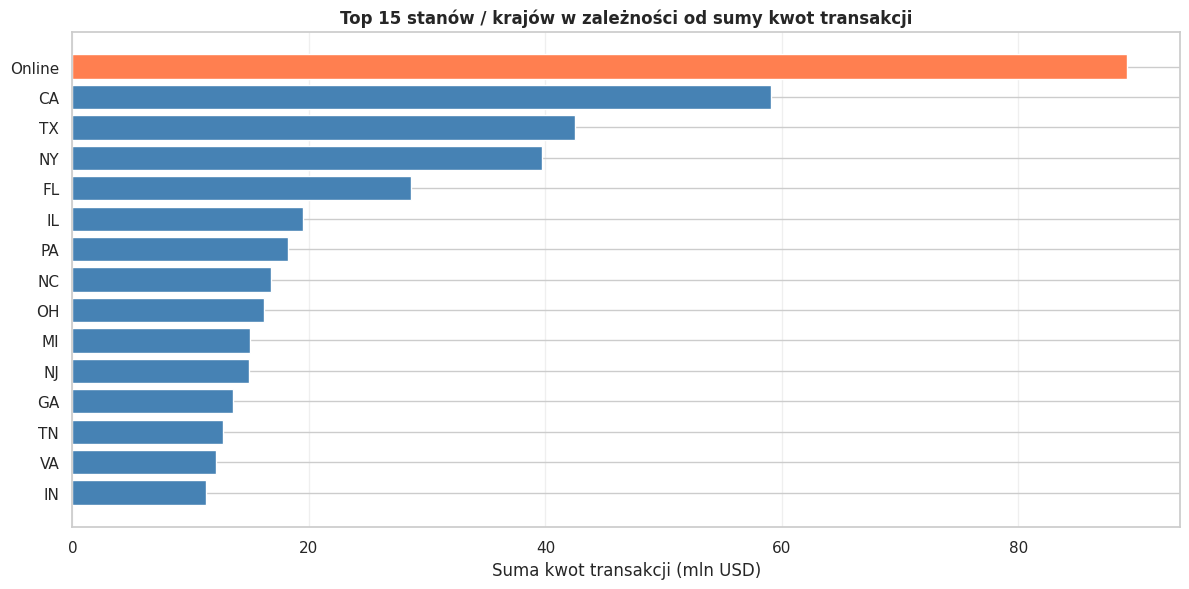

In [10]:
analysis.plot_graph(plot_top_states_by_amount, analysis.transactions, top_n=15)

Ale procent transakcji oszukańczych względem każdego ze stanów mówi zupełnie inaczej!

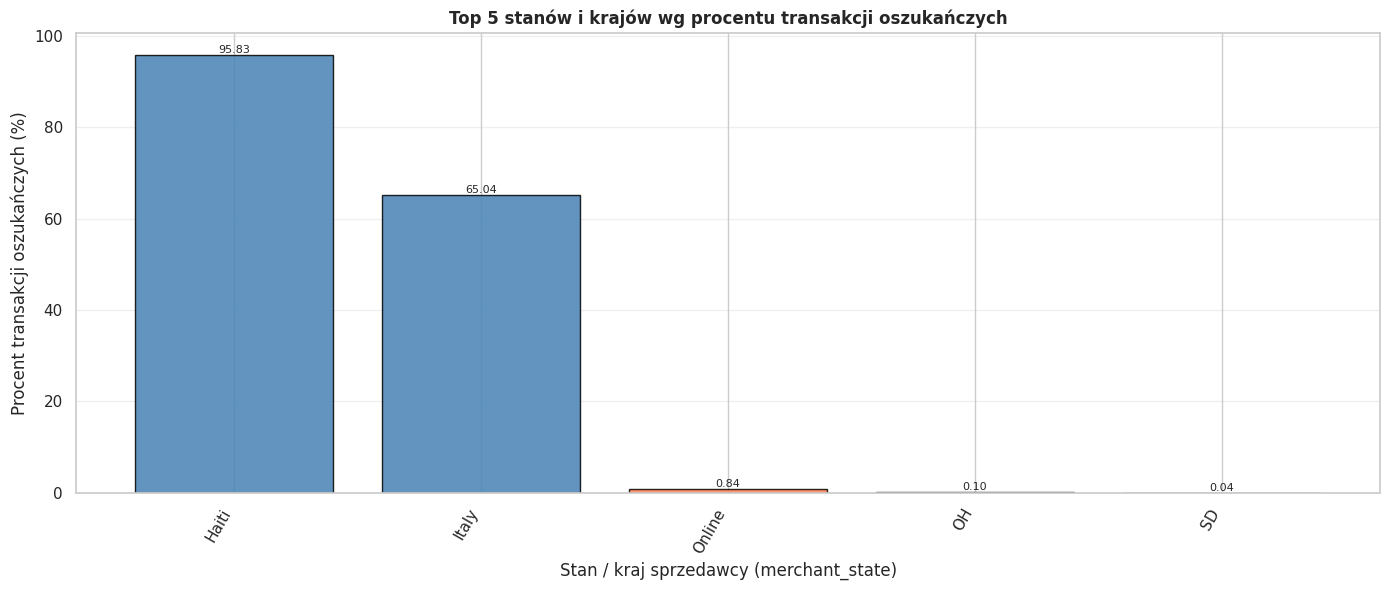

In [11]:
analysis.plot_graph(
    plot_state_fraud_rate,
    load_all_transactions(),
    top_n=5,
    min_transactions=100,
)

Tak samo z poszukiwaniem branż, gdzie najczęściej odbywają się oszustwa: sklepy nie są dobrym wyznacznikiem

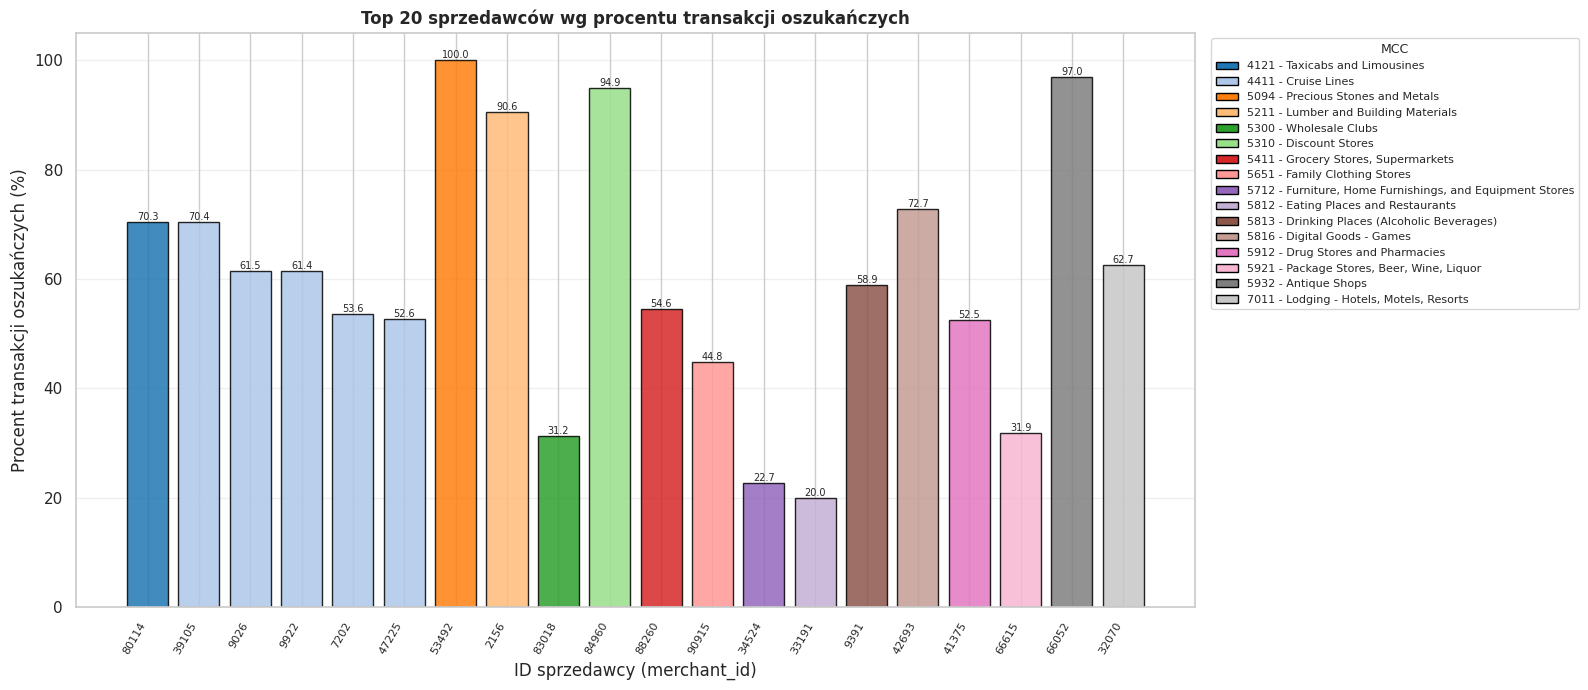

In [12]:
analysis.plot_graph(
    plot_merchant_fraud_rate,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    top_n=20,
    min_transactions=50,
)

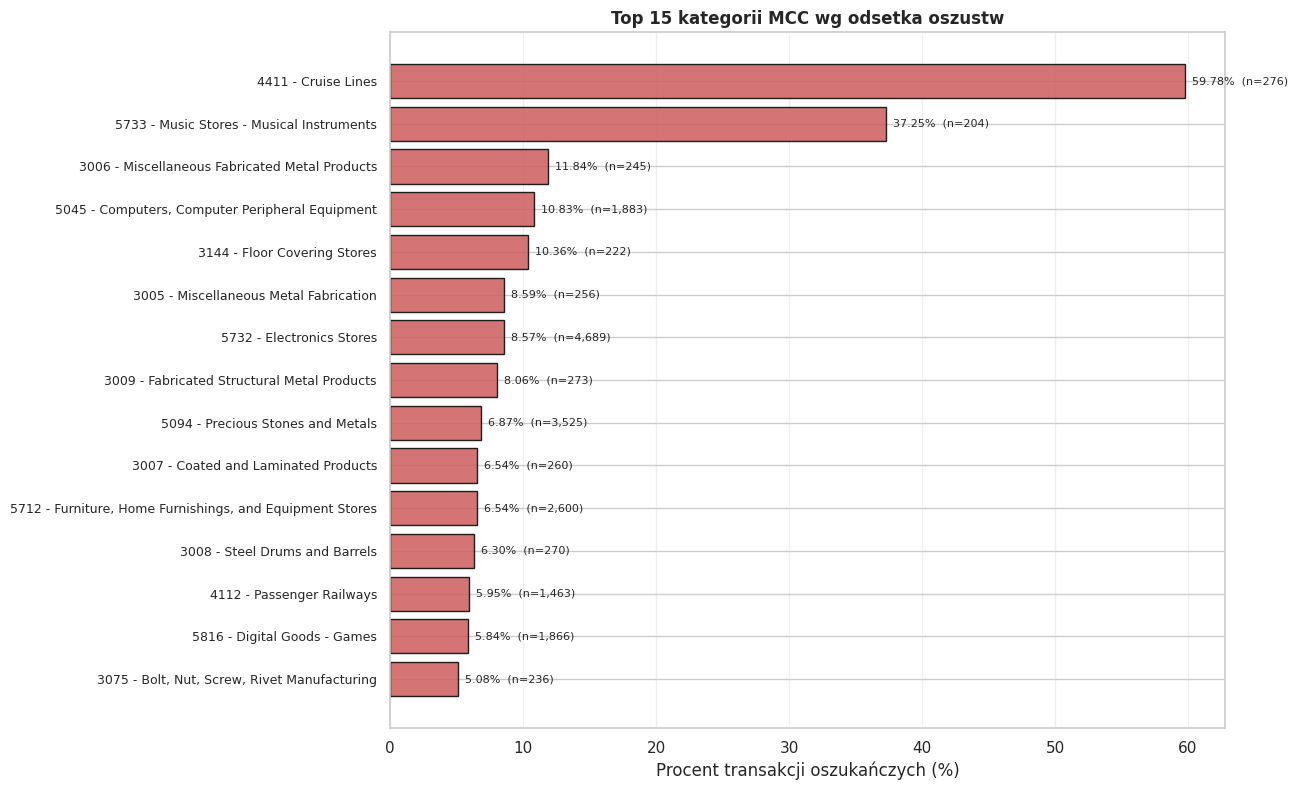

In [13]:
analysis.plot_graph(
    plot_mcc_fraud_rate,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    top_n=15,
    min_transactions=50,
)

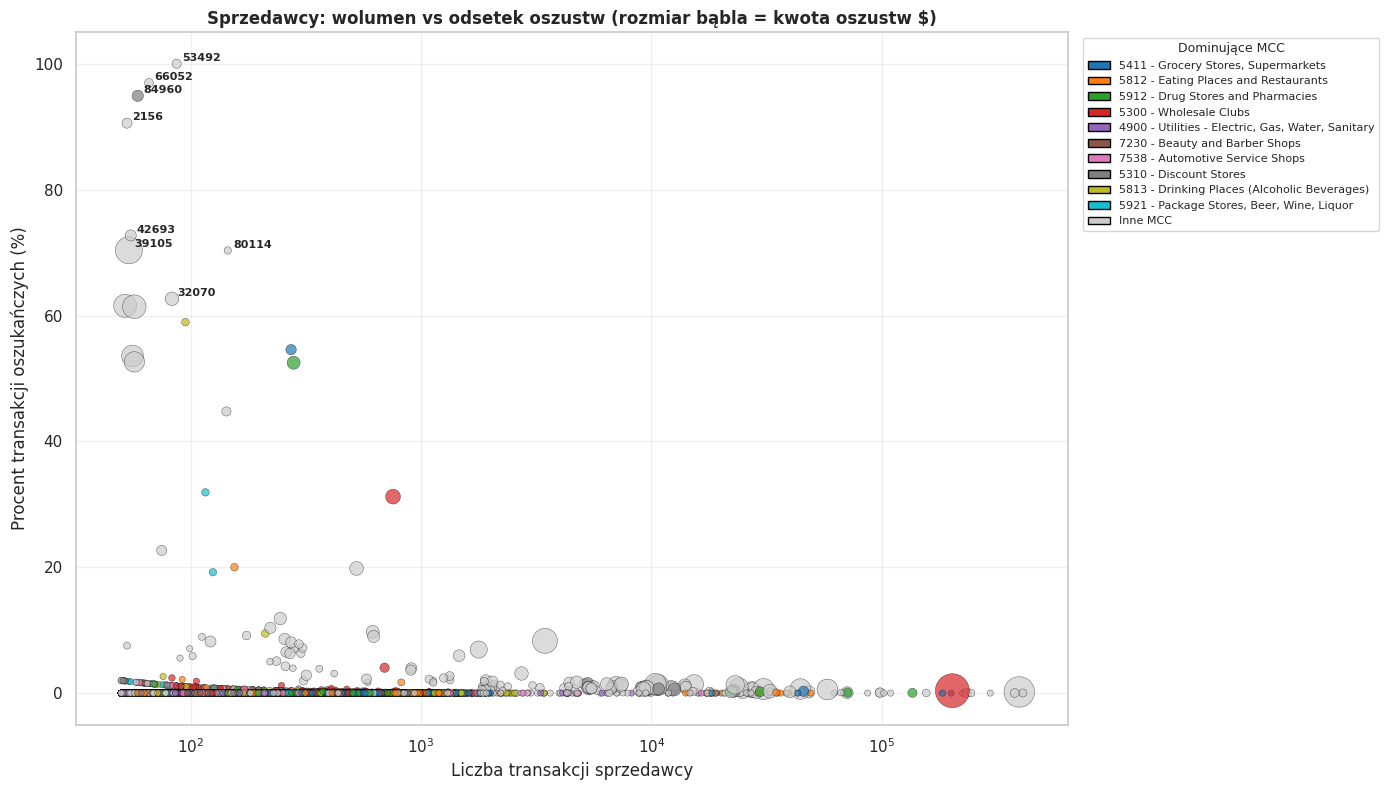

In [14]:
analysis.plot_graph(
    plot_merchant_fraud_rate_volume,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    min_transactions=50,
)

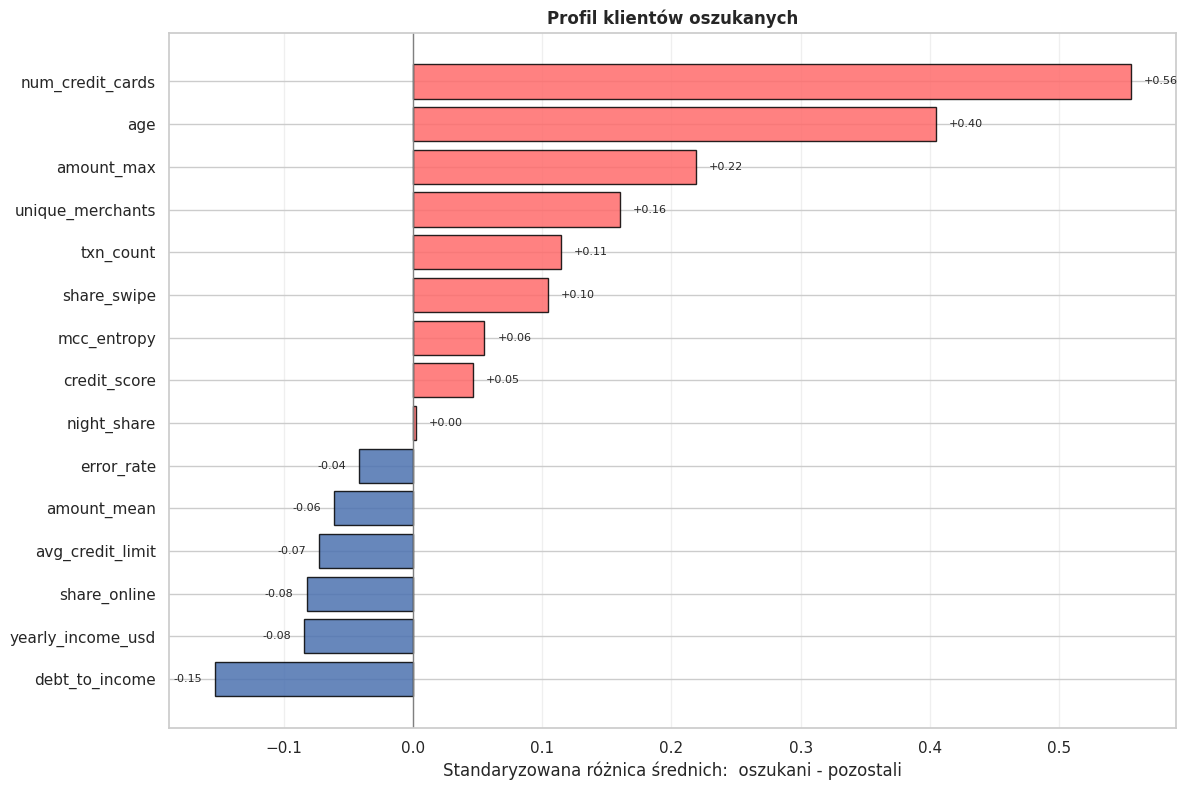

In [19]:
profile = build_client_fraud_profile(analysis.transactions, analysis.users, analysis.cards, min_fraud_txns=10)
analysis.plot_graph(plot_fraud_profile, profile)

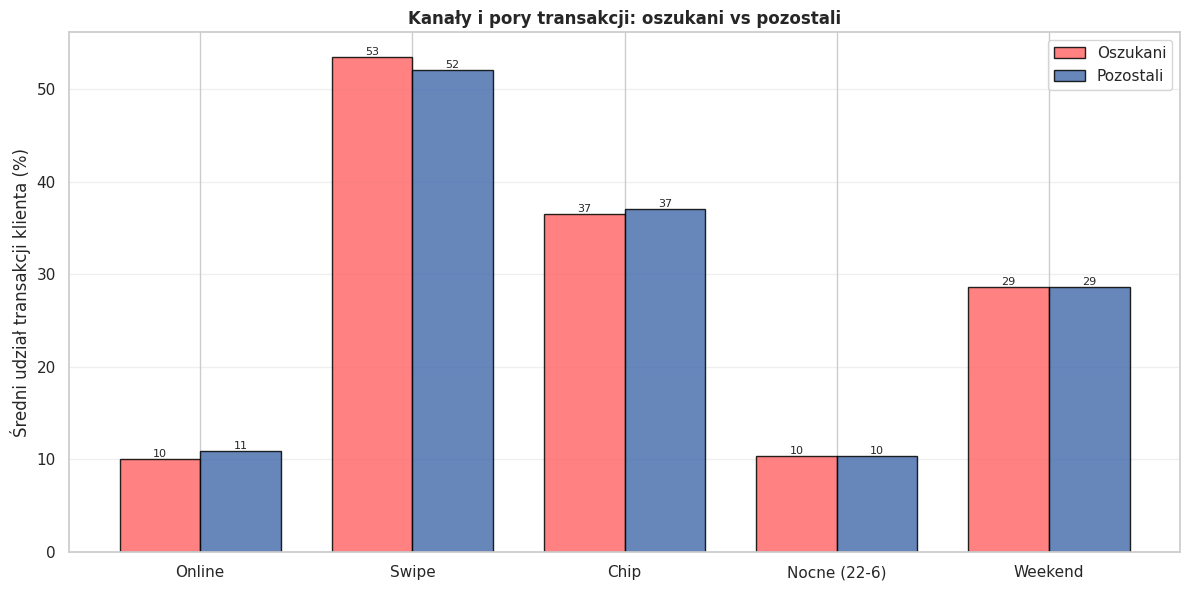

In [16]:
analysis.plot_graph(plot_fraudster_channel_mix, profile)

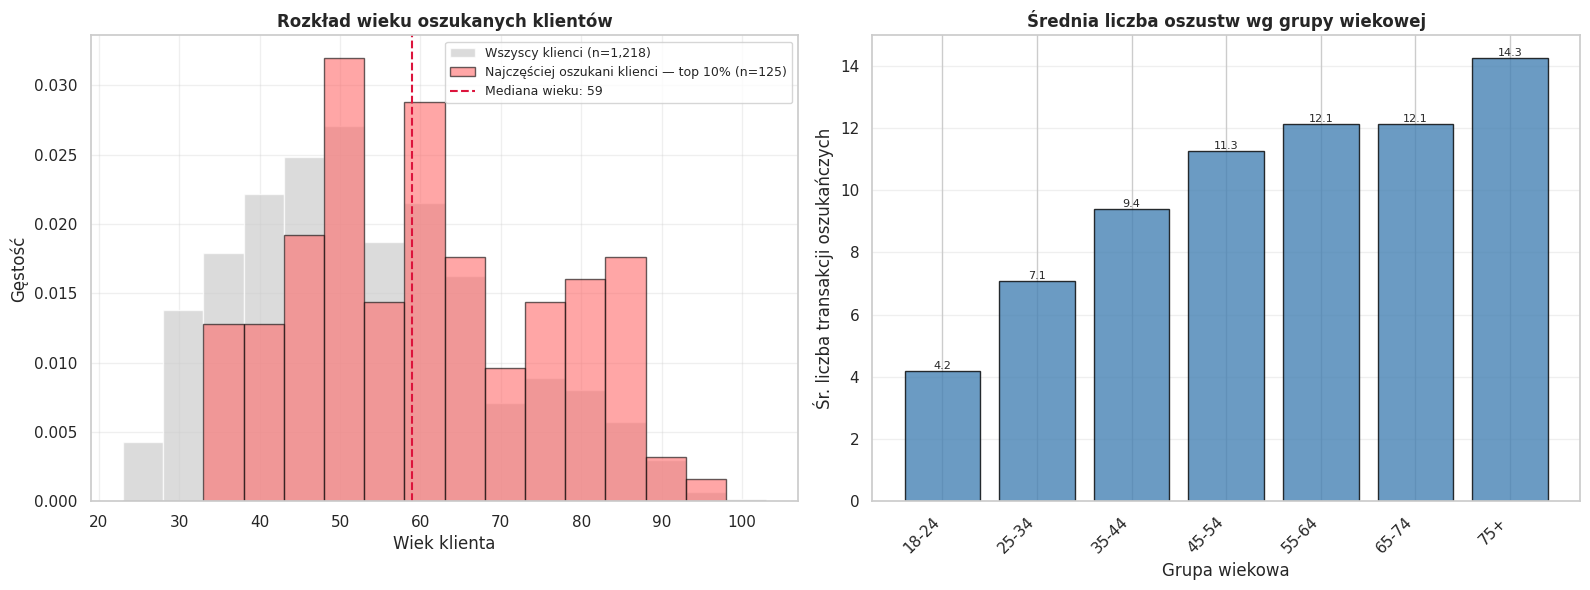

In [17]:
analysis.plot_graph(plot_fraud_frequent_age, profile, top_frac=0.1)

Oprócz profilowania oszust, przeprowadziliśmy także badanie zbioru, aby lepiej zrozumieć istniejące zależności.

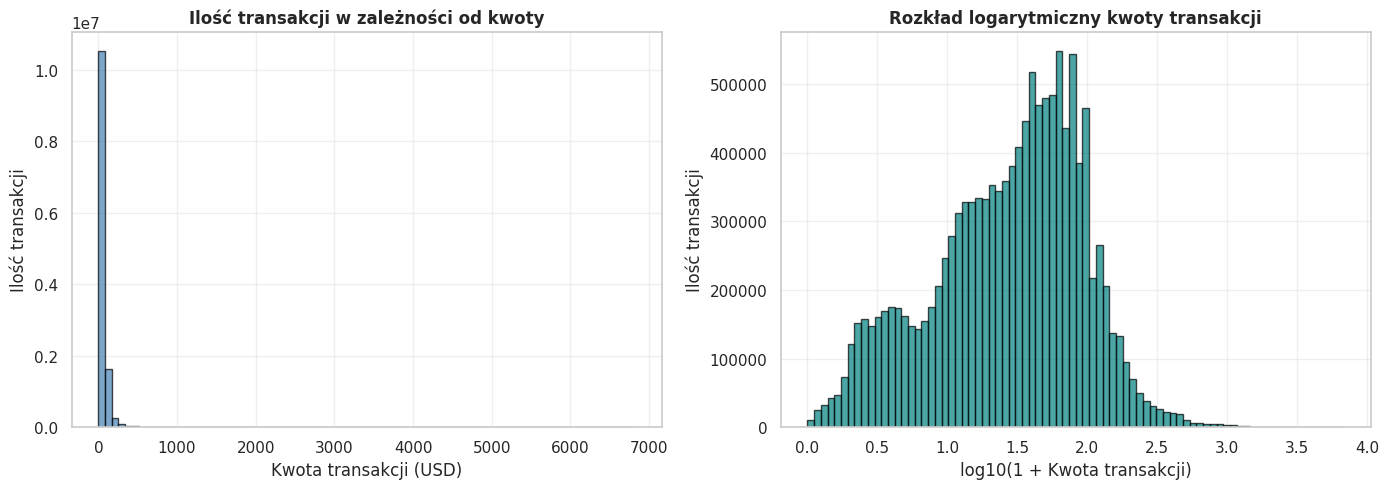

In [21]:
analysis.plot_graph(plot_amount_distribution, analysis.transactions)

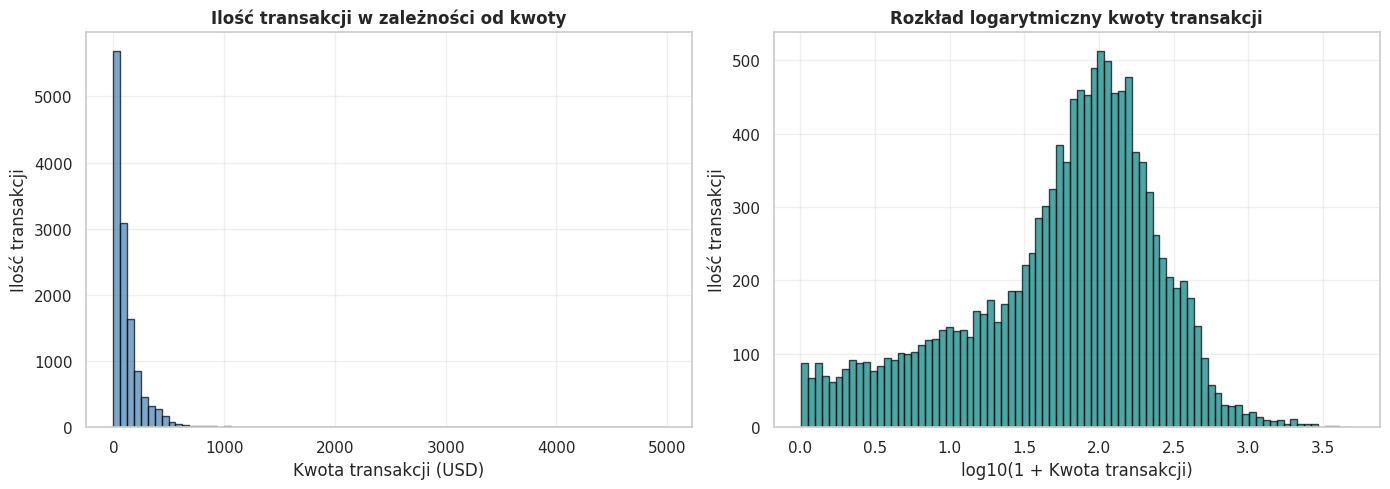

In [34]:
from transaction_analysis.data.loader import load_fraud_transactions

analysis_fraud = TransactionAnalysis(load_fraud_transactions(), output_dir=PLOTS_DIR)

analysis_fraud.plot_graph(plot_amount_distribution, analysis_fraud.transactions)

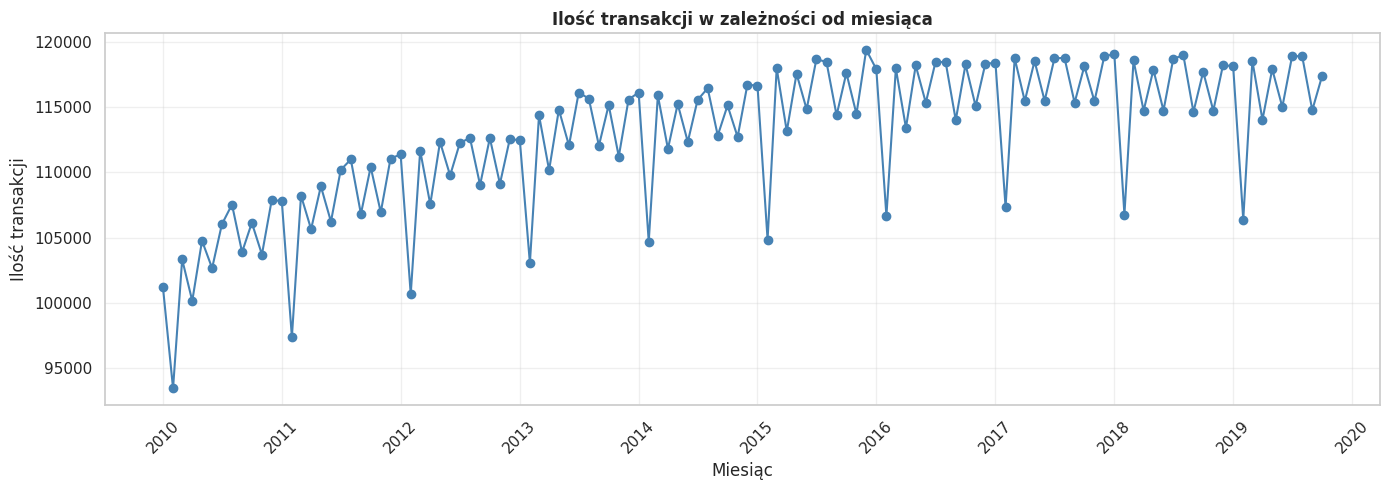

In [22]:
analysis.plot_graph(plot_transactions_over_time, analysis.transactions)

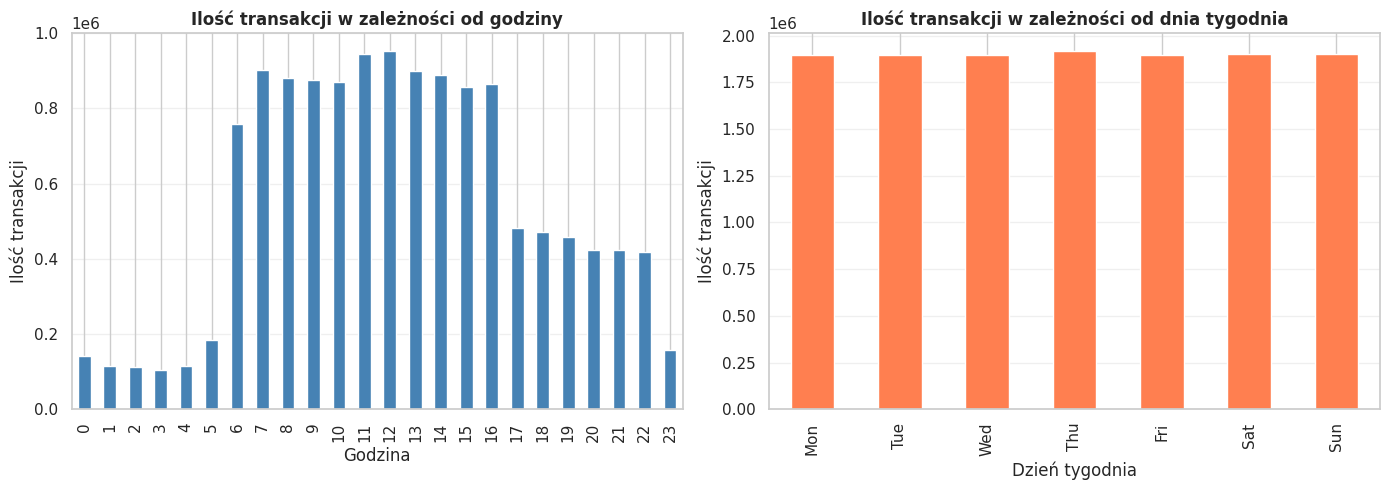

In [23]:
analysis.plot_graph(plot_time_patterns, analysis.transactions)

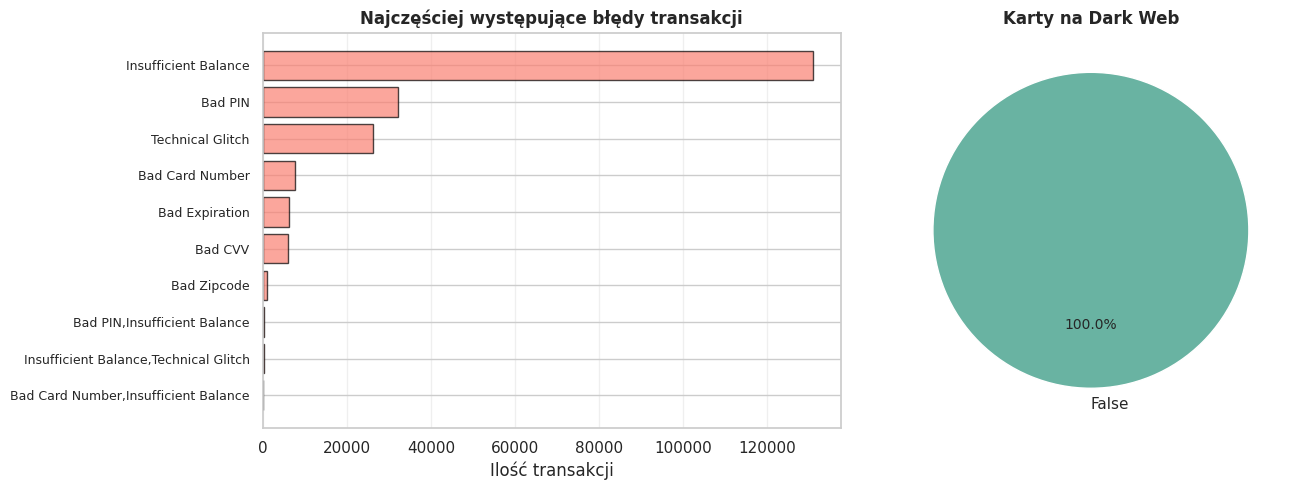

In [24]:
analysis.plot_graph(plot_errors_and_darkweb, analysis.transactions, analysis.cards)

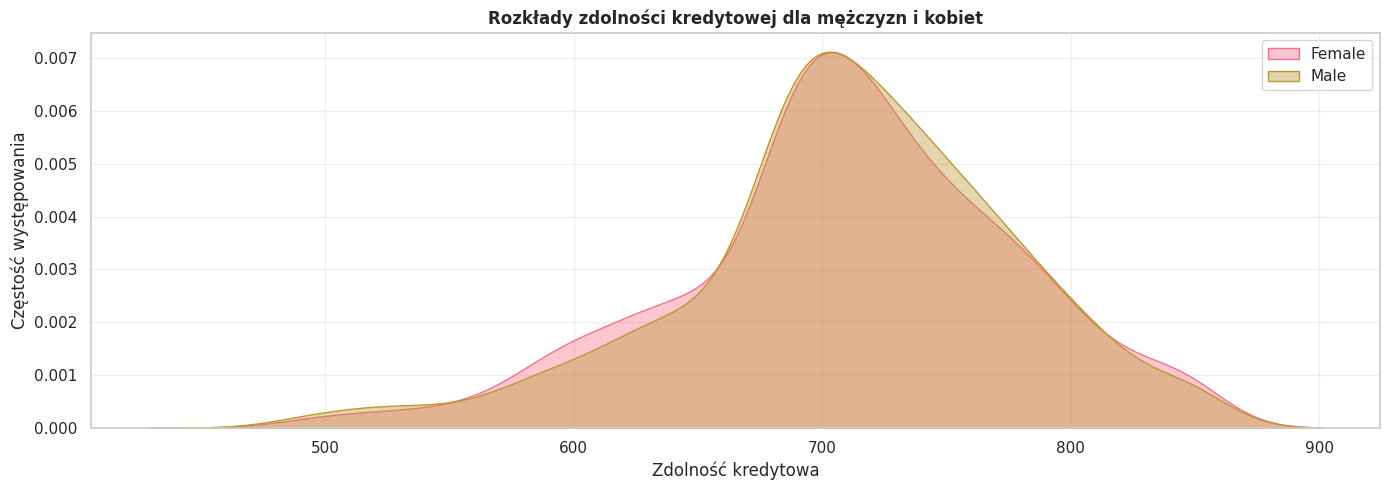

In [25]:
analysis.plot_graph(plot_credit_score_by_gender, analysis.users)

Oszukańcze transakcje mają znacznie inny rozkład ilości transakcji oraz sumy kwot niż transakcje legalne.

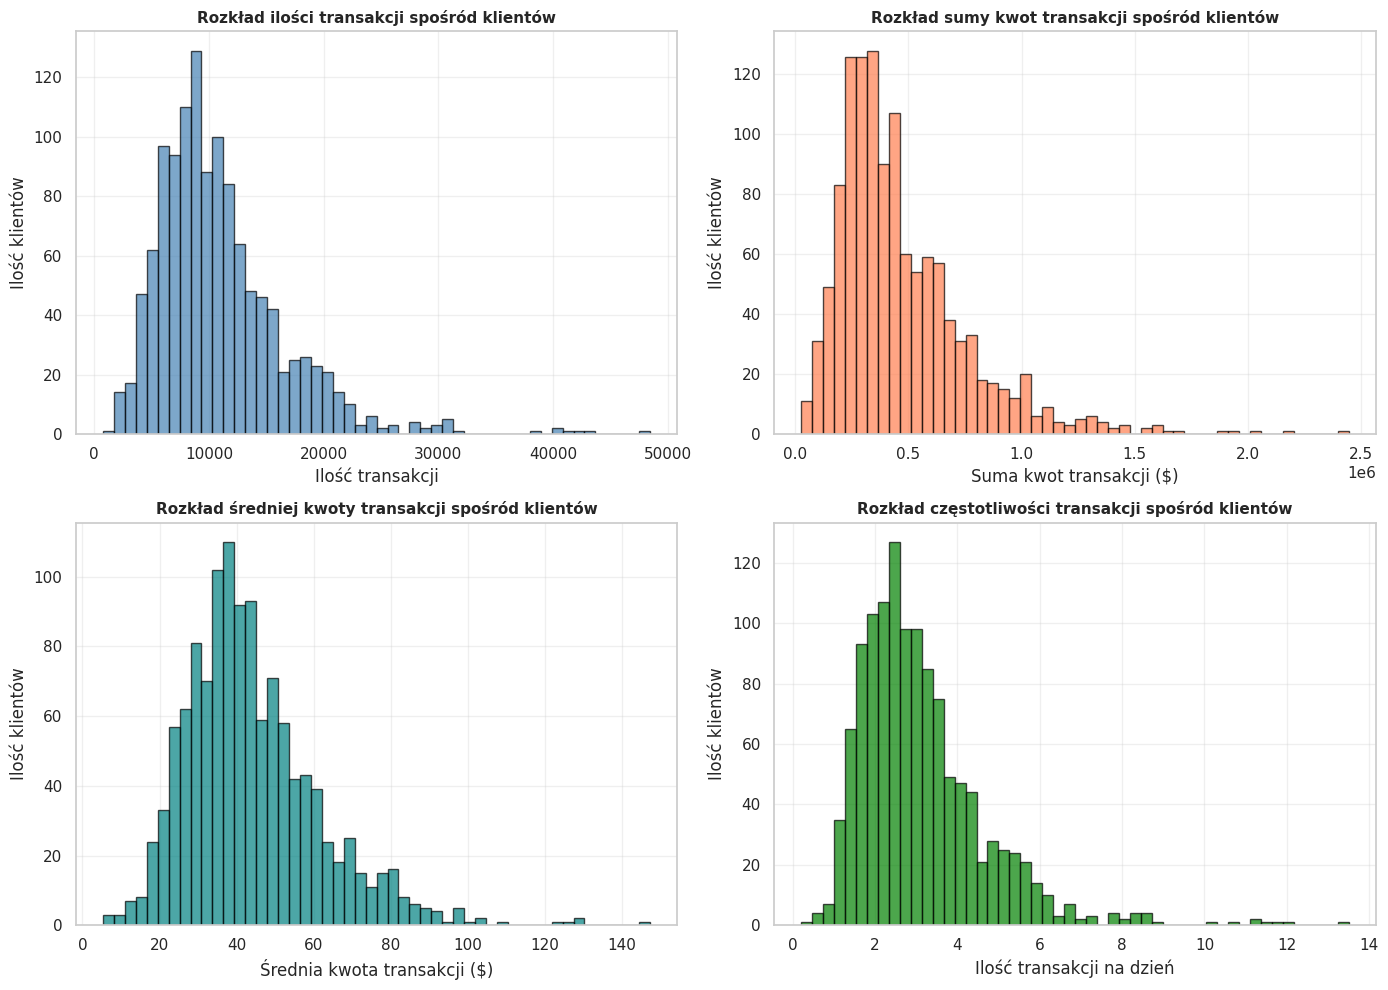

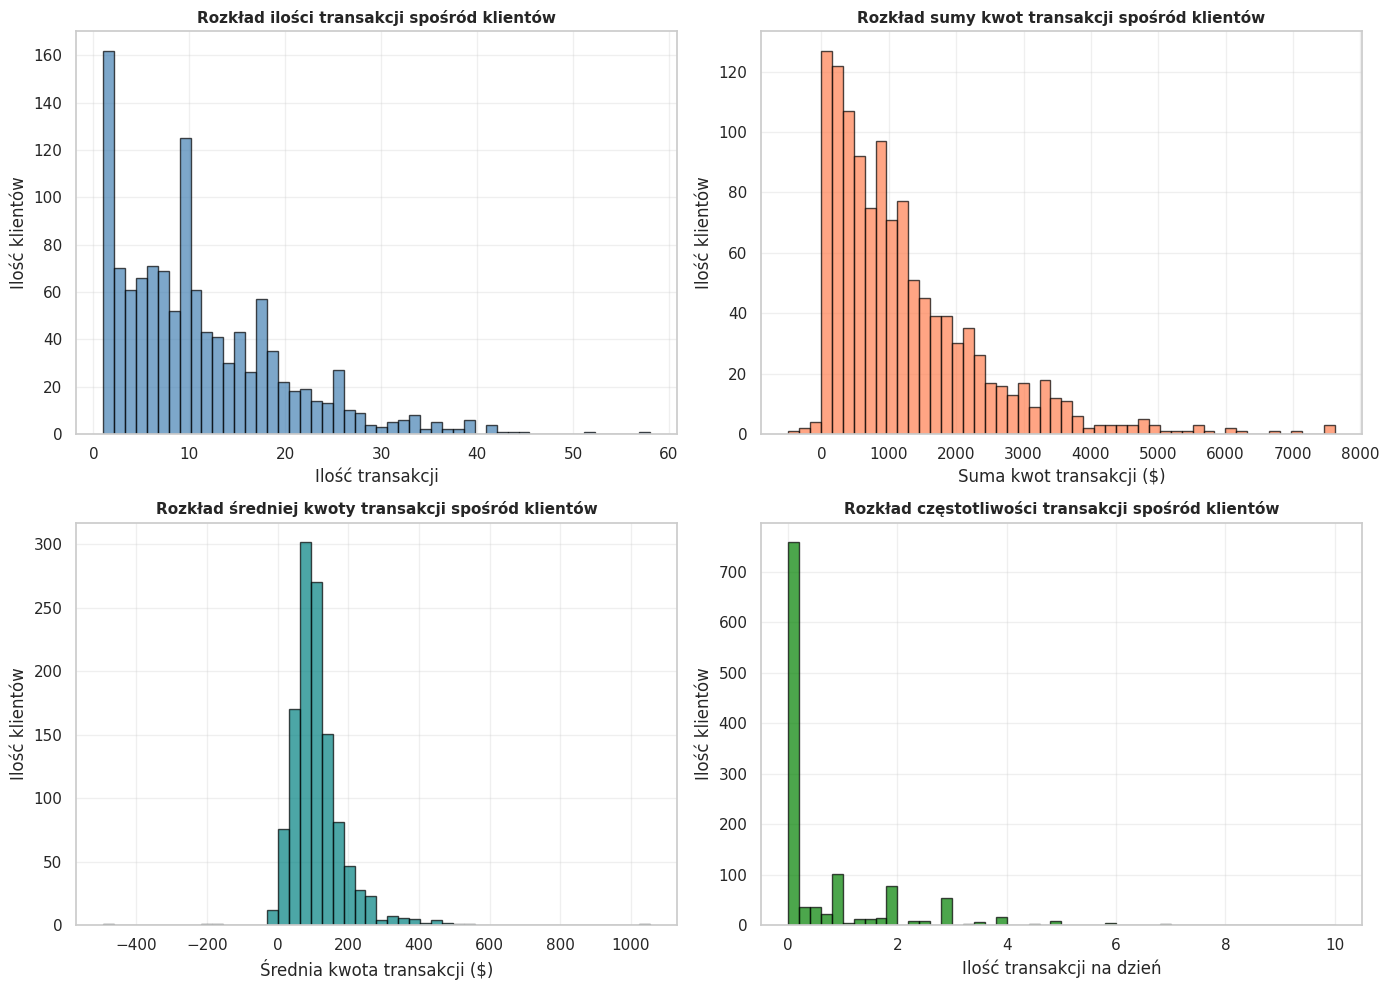

In [35]:
analysis.plot_graph(plot_user_transaction_distribution, analysis.user_agg)
analysis_fraud.plot_graph(plot_user_transaction_distribution, analysis_fraud.user_agg)

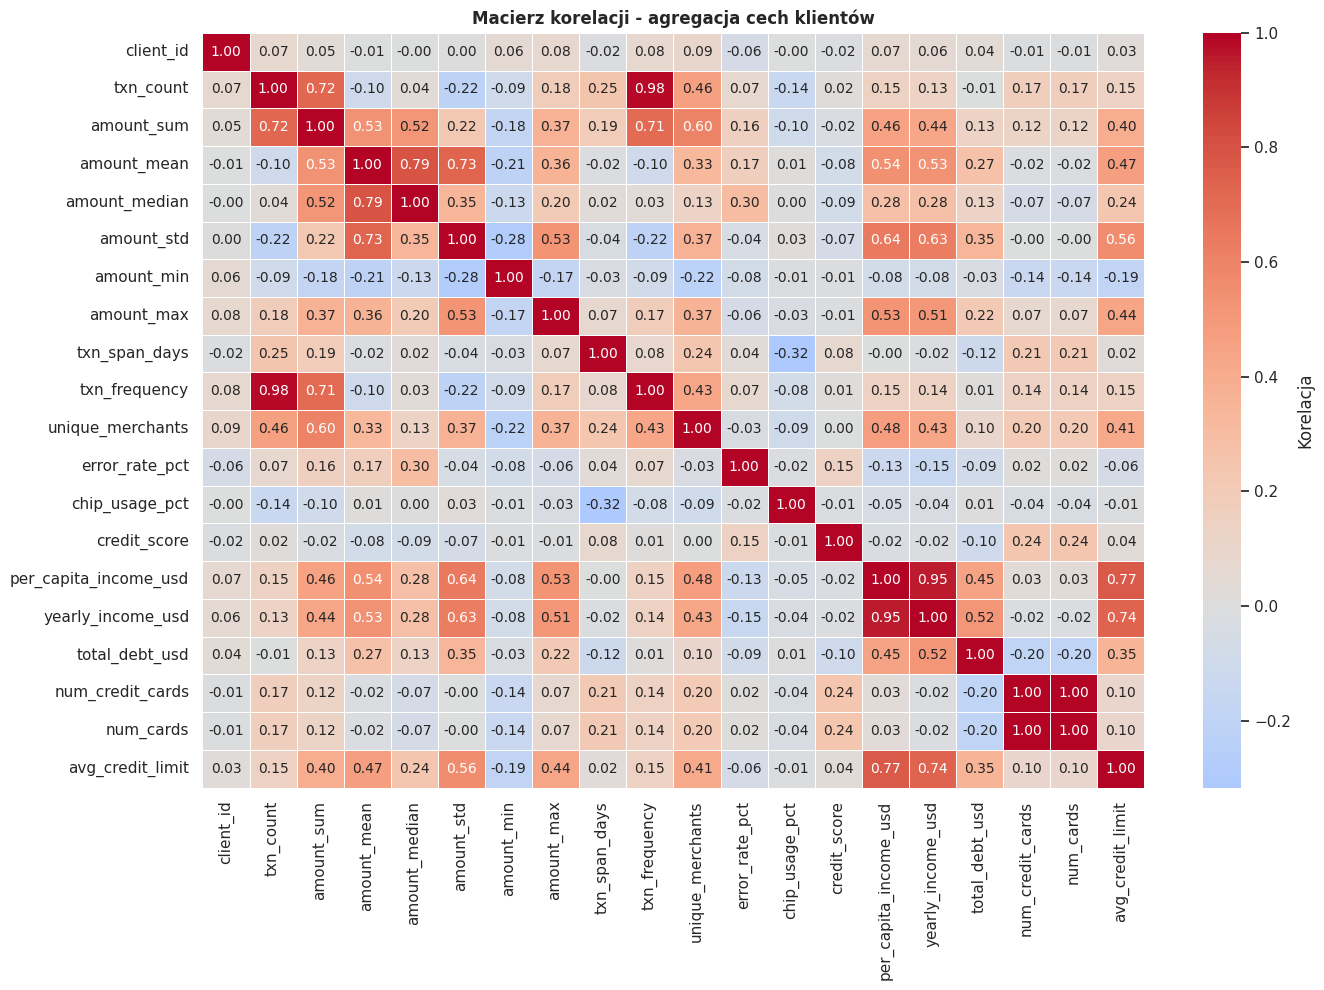

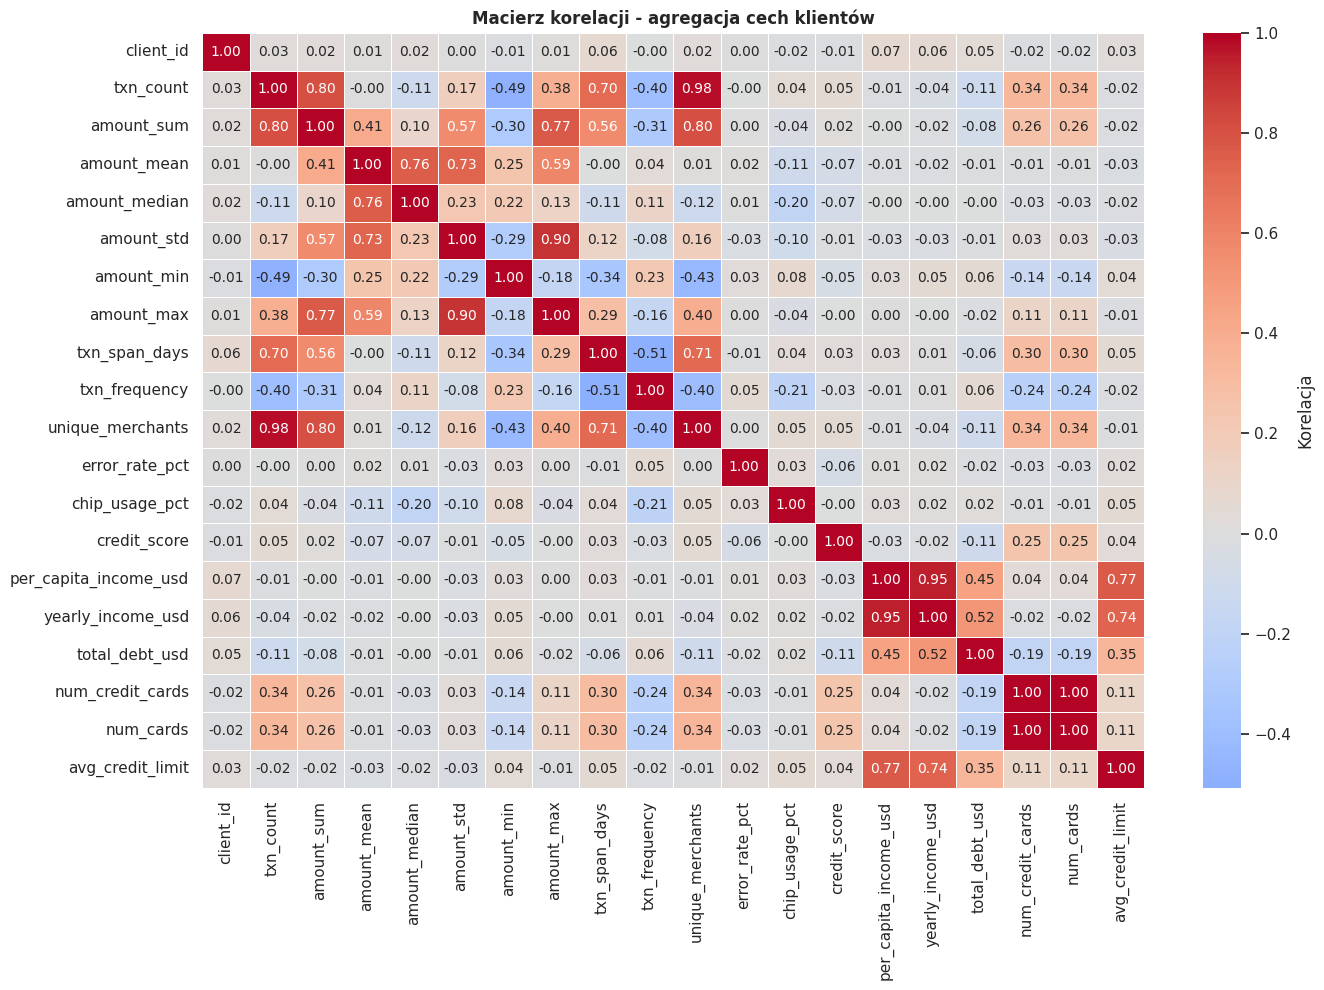

In [36]:
analysis.plot_graph(plot_correlation_heatmap, analysis.user_agg)
analysis_fraud.plot_graph(plot_correlation_heatmap, analysis_fraud.user_agg)

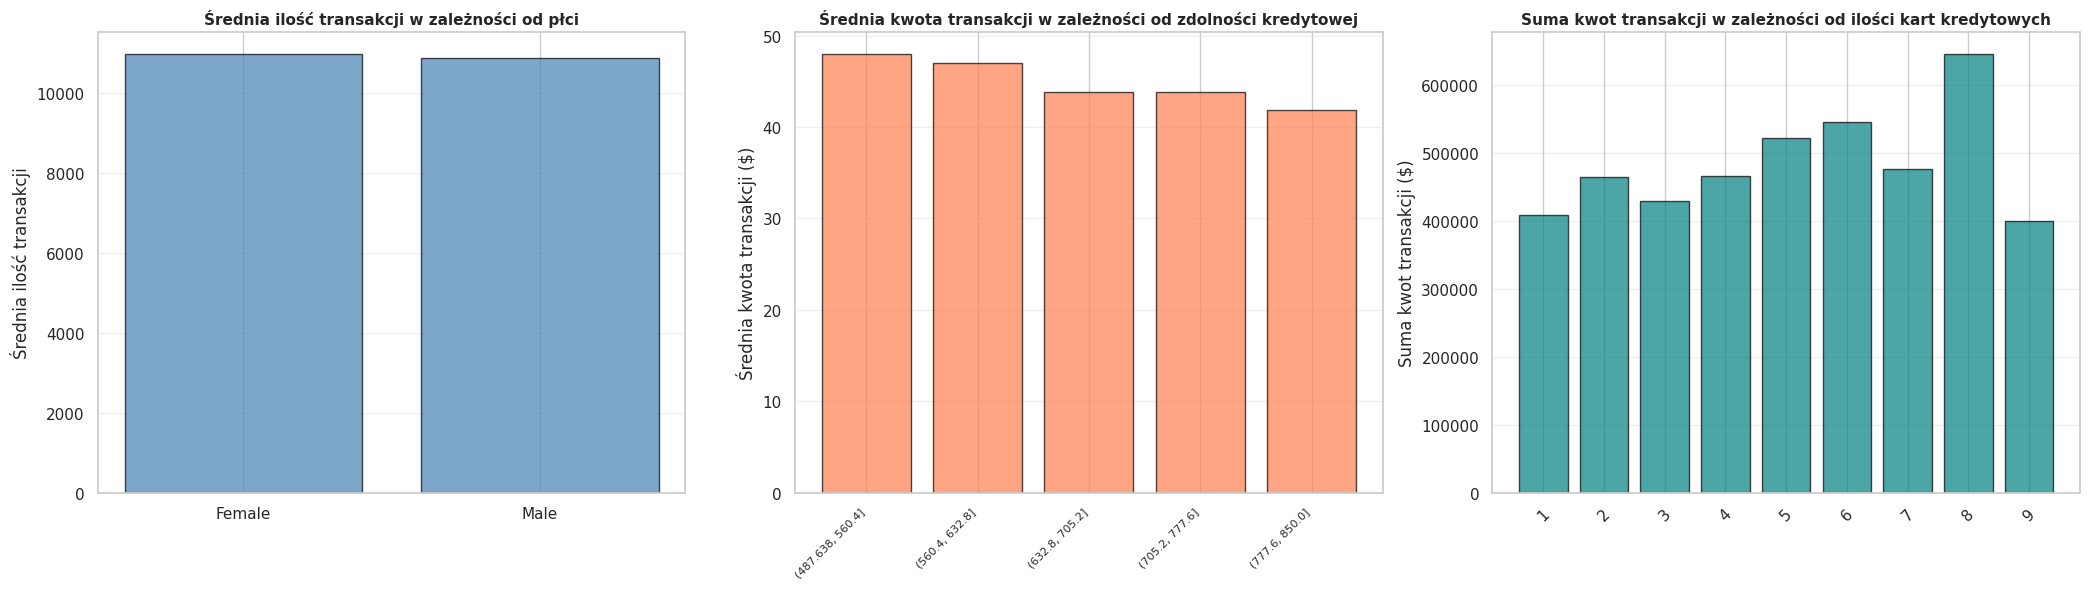

In [28]:
analysis.plot_graph(plot_demographic_patterns, analysis.user_agg)

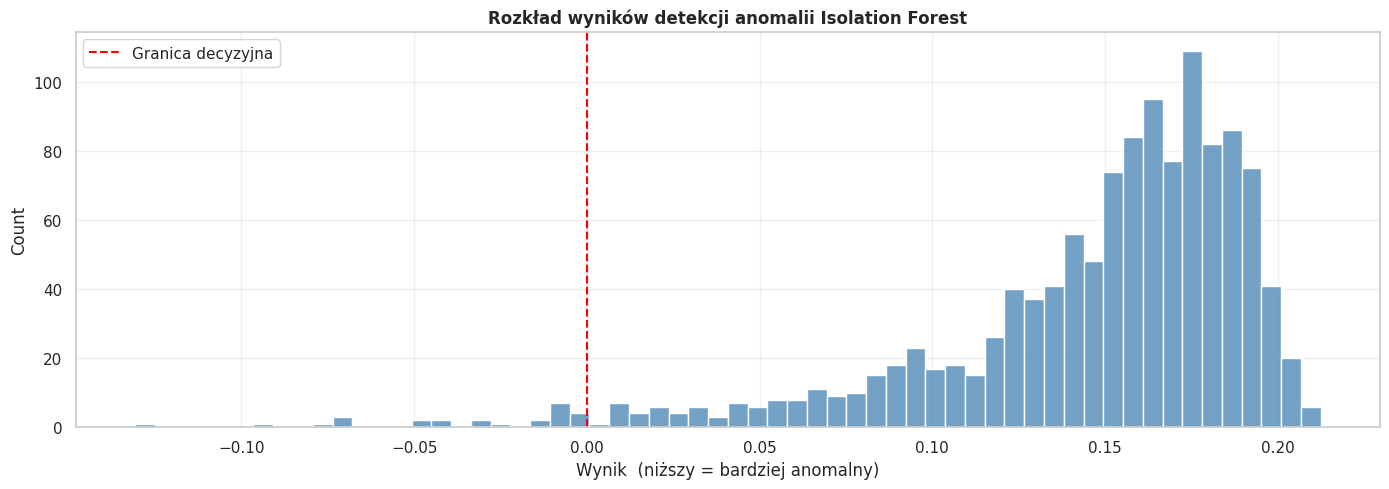

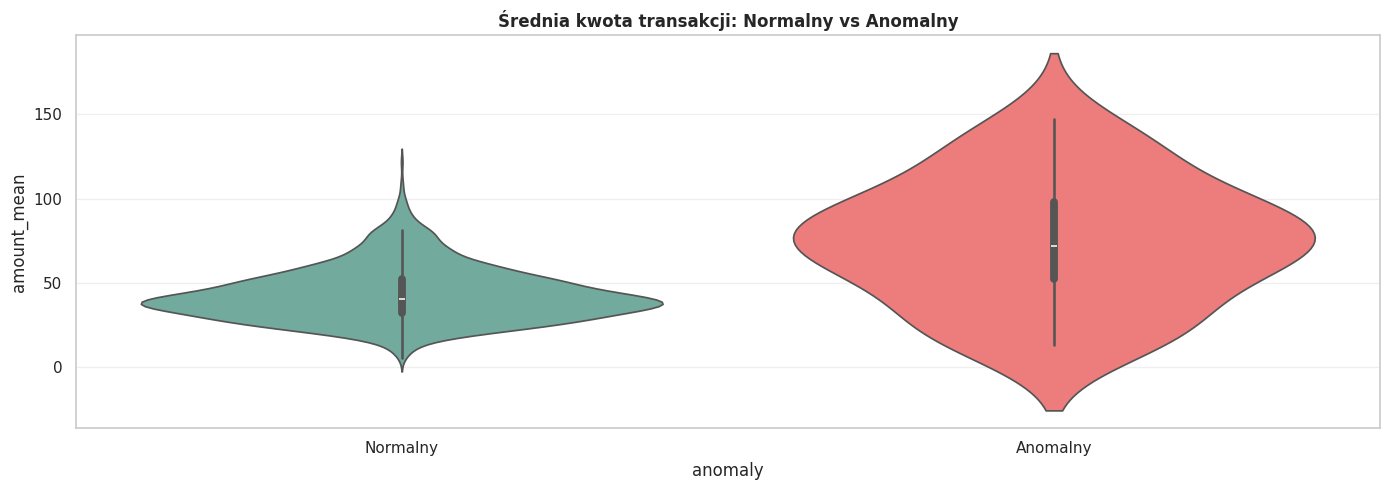

In [30]:
anomalous_user_agg, _ = anomaly_analysis(analysis.user_agg)
analysis.plot_graph(plot_anomalies, anomalous_user_agg)

Istnieje ciekawa rozbieżność pomiędzy transakcjami normalnymi a oszustwami w USA.

Using existing shapefiles, skipping download. Use `force=True` to re-download.


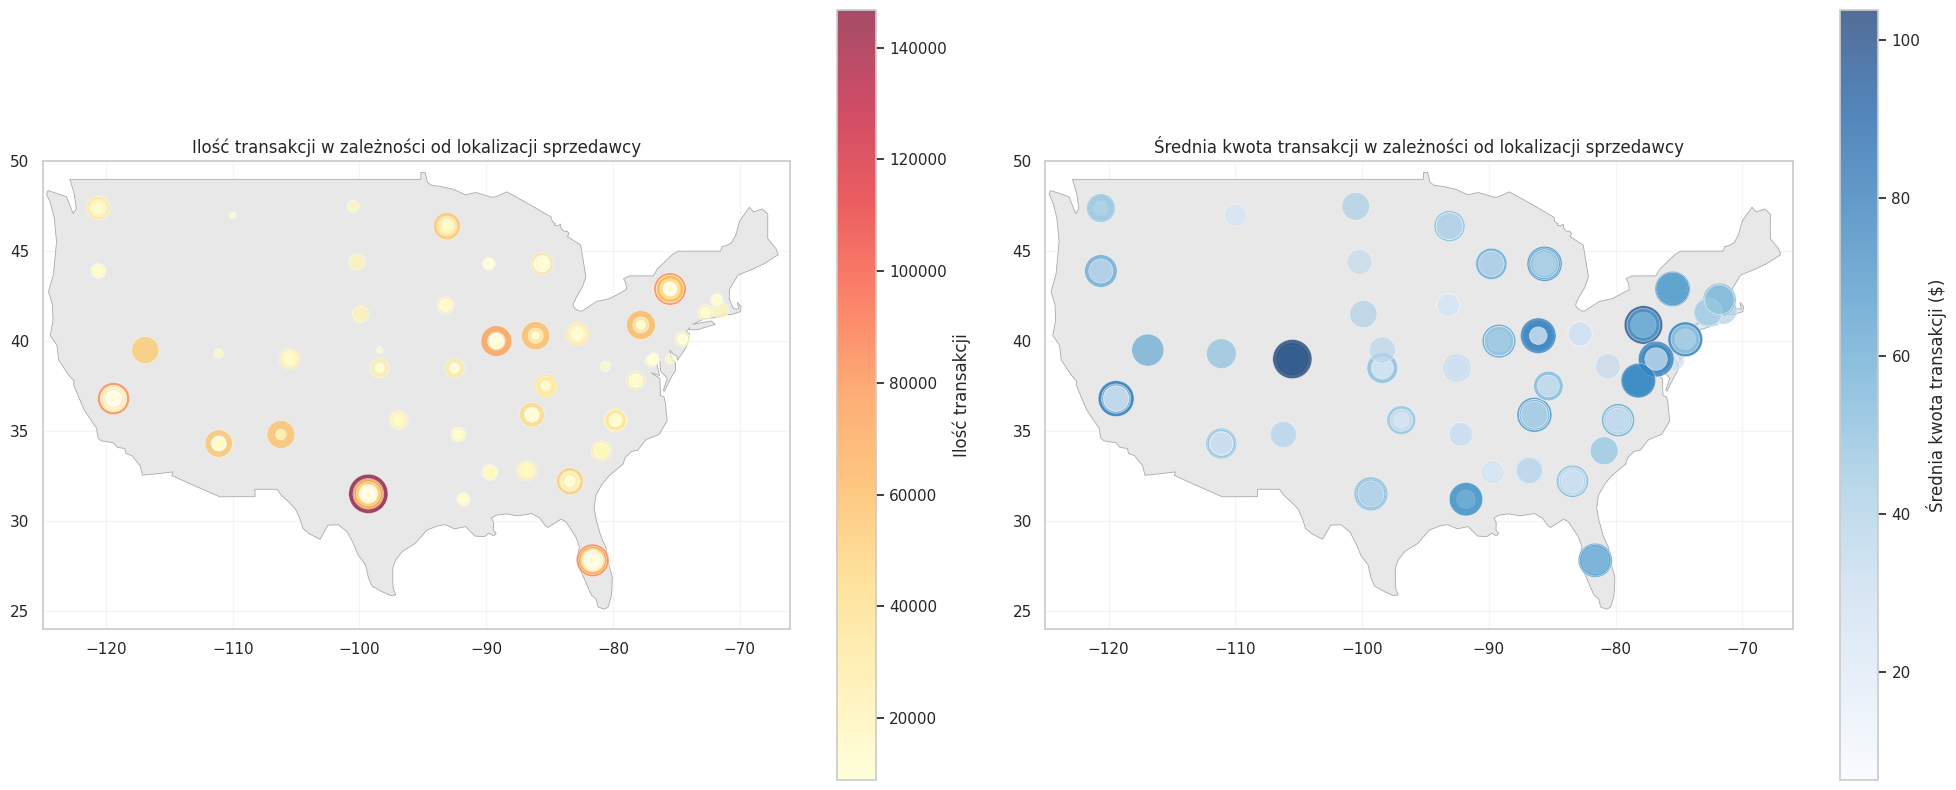

Using existing shapefiles, skipping download. Use `force=True` to re-download.


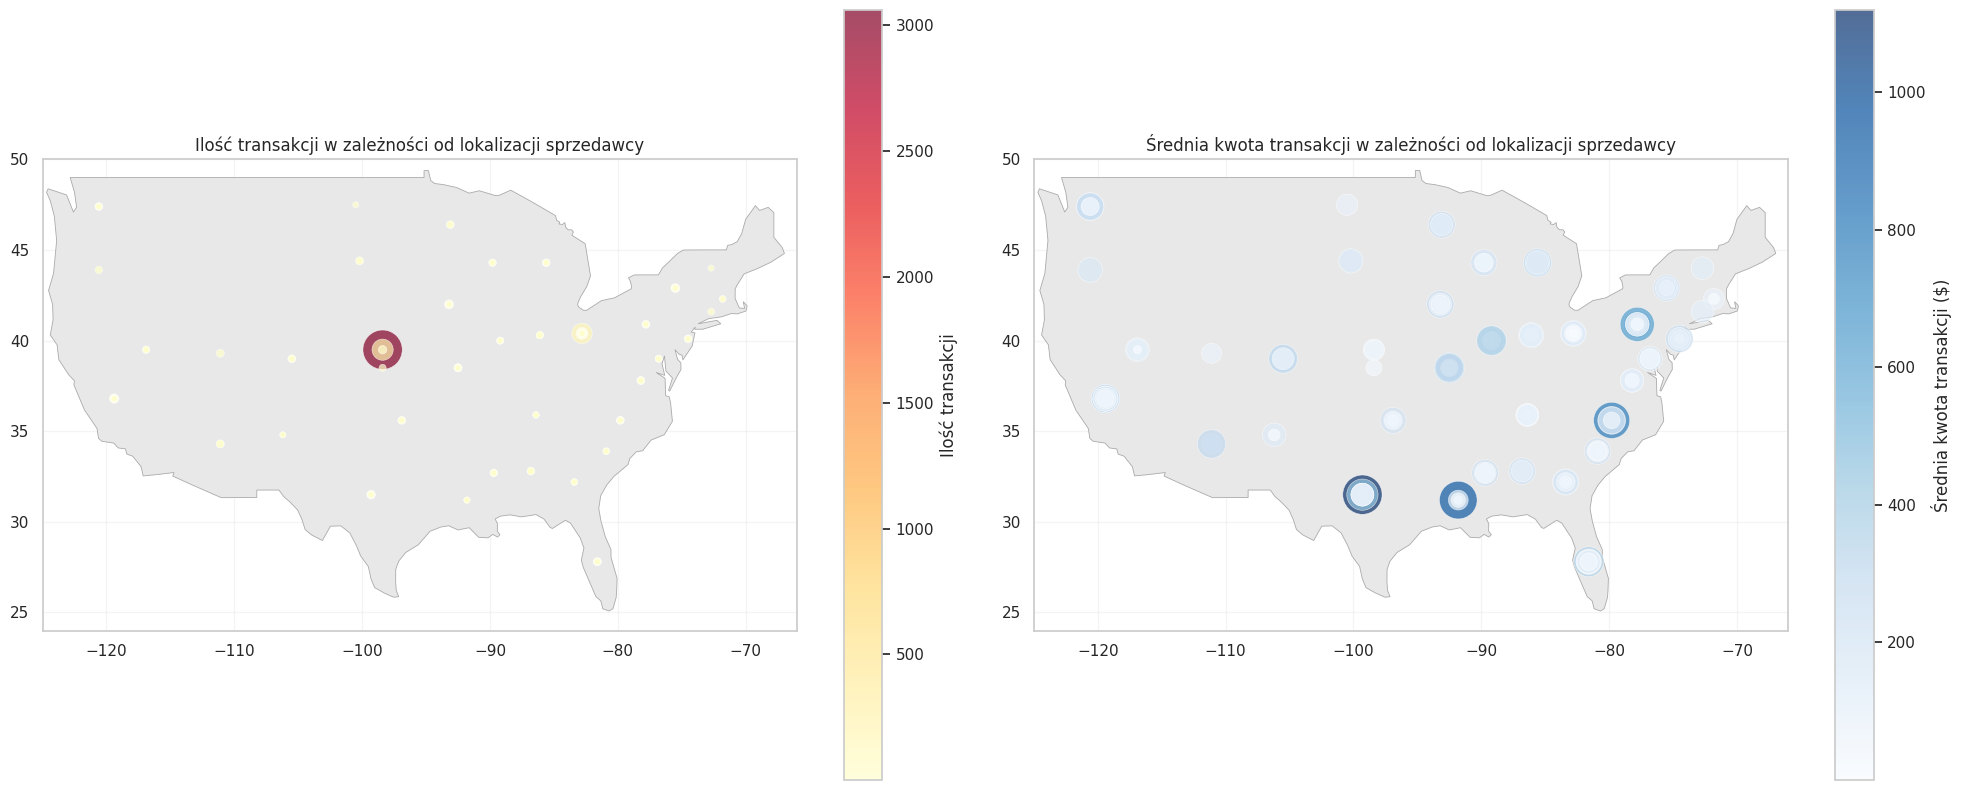

In [37]:
analysis.plot_graph(plot_us_transaction_map, analysis.transactions)
analysis_fraud.plot_graph(plot_us_transaction_map, analysis_fraud.transactions)

## 6. PCA

In [ ]:
fraud_labels = pd.read_parquet(FRAUD_DATASET_DIR / "cleaned" / "fraud_labels.parquet")
pca = run_user_pca(
    transactions=analysis.transactions,
    users=analysis.users,
    cards=analysis.cards,
    fraud_labels=fraud_labels,
    n_components=6,
    n_clusters=4,
)

In [5]:
top_pcs = pd.DataFrame(
    {pc: pca.loadings[pc].abs().sort_values(ascending=False).head(6).index.tolist() for pc in pca.loadings.columns}
)
top_pcs

,PC1,PC2,PC3,PC4,PC5,PC6
0,unique_mcc,num_credit_cards,mcc_entropy,share_swipe,amount_median,error_rate
1,amount_sum,num_cards,txn_count,share_chip,debt_to_income,amount_median
2,avg_credit_limit,age,share_online,chip_share,total_debt_usd,credit_score
3,amount_mean,debt_to_income,amount_sum,avg_card_age_years,age,unique_merchants
4,amount_std,total_debt_usd,amount_std,num_cards,avg_card_age_years,share_online
5,unique_merchants,total_credit_limit,share_swipe,num_credit_cards,amount_mean,amount_mean


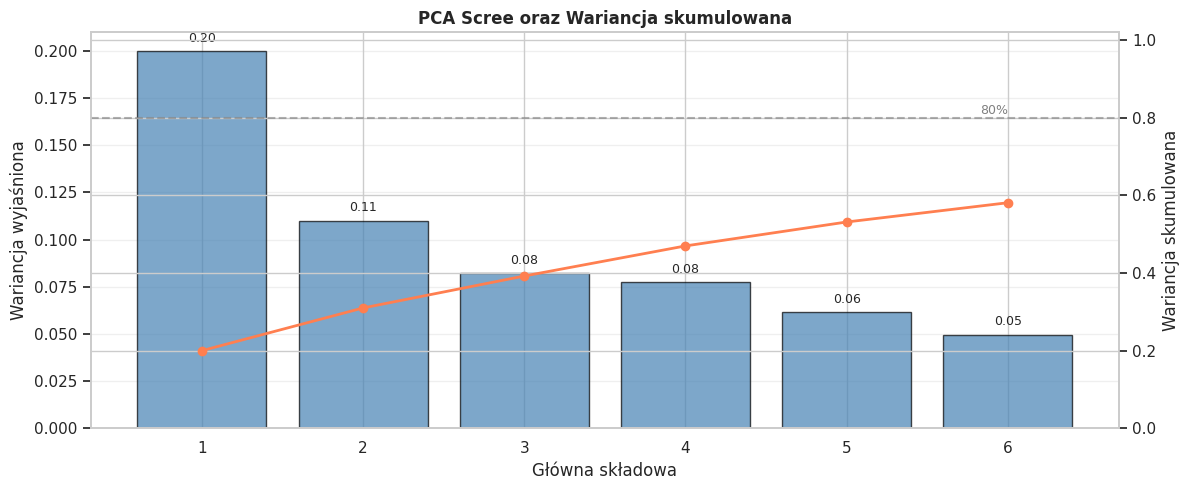

In [12]:
from transaction_analysis.eda.visualizations import (
    plot_pca_biplot,
    plot_pca_clusters,
    plot_pca_fraud_overlay,
    plot_pca_scree,
)

analysis.plot_graph(plot_pca_scree, pca.explained_variance)

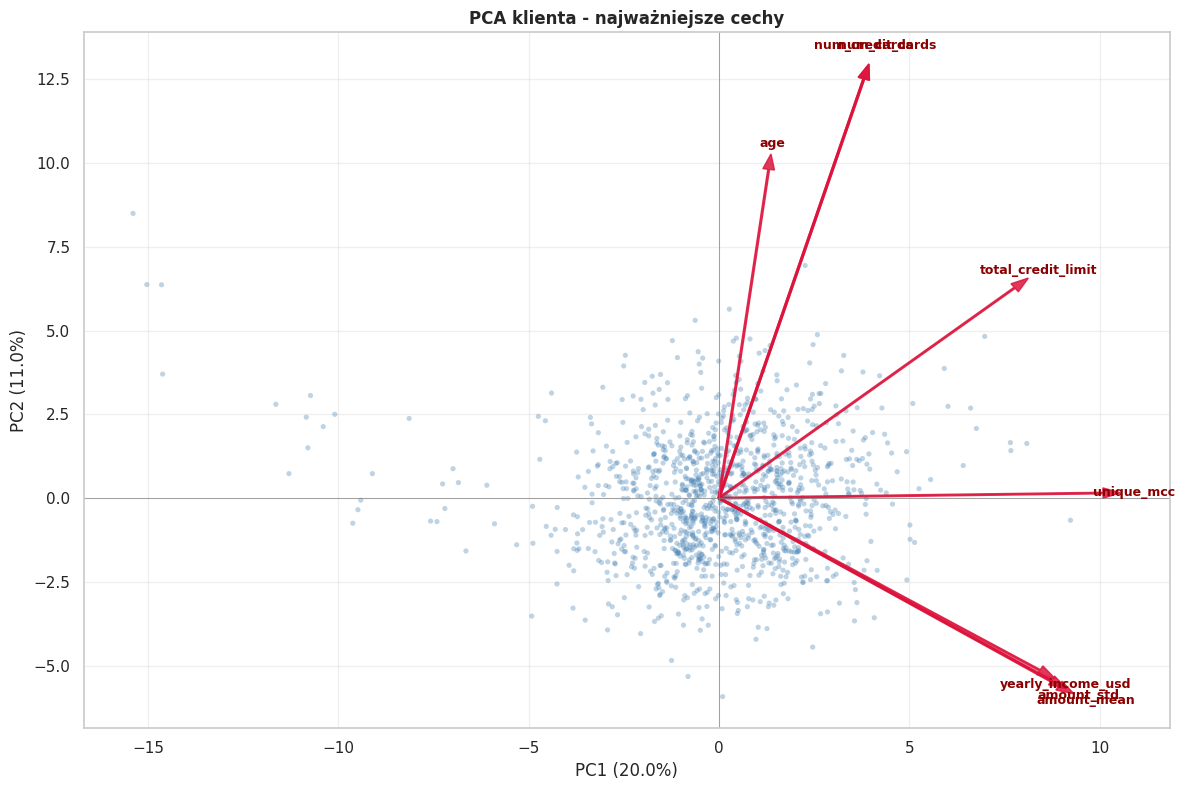

In [9]:
analysis.plot_graph(plot_pca_biplot, pca.scores, pca.loadings, pca.explained_variance)

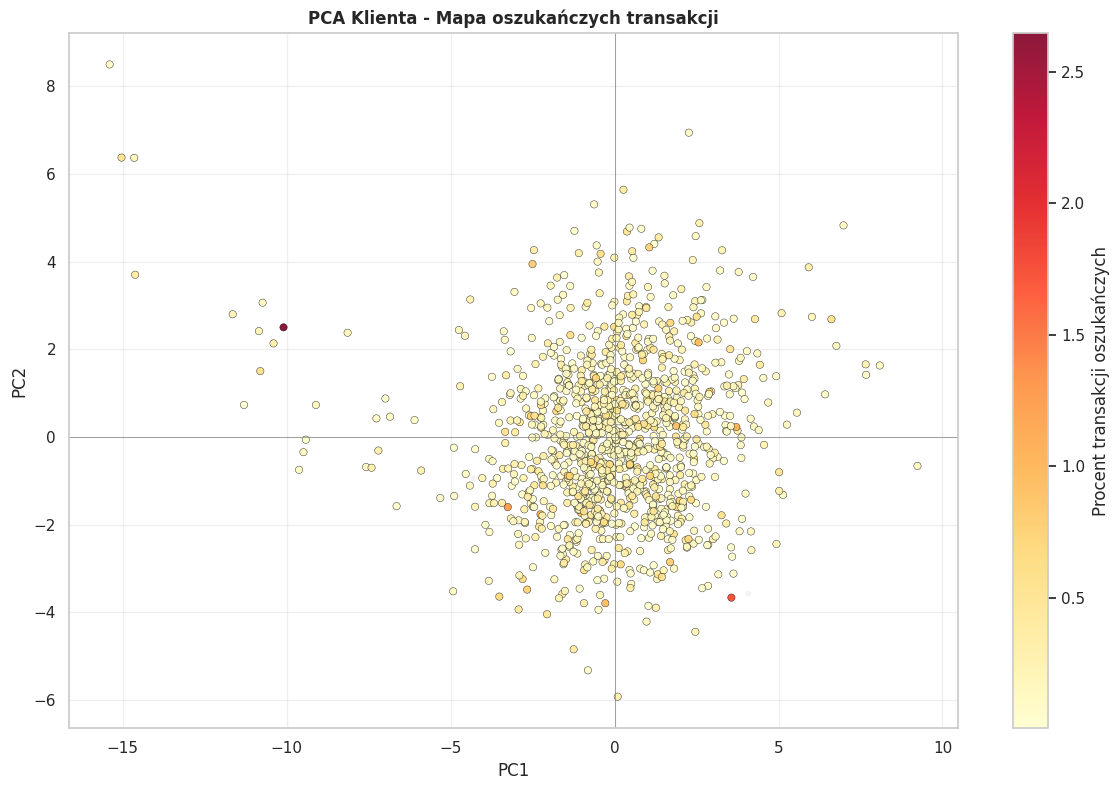

In [11]:
analysis.plot_graph(plot_pca_fraud_overlay, pca.scores, pca.fraud_rate)

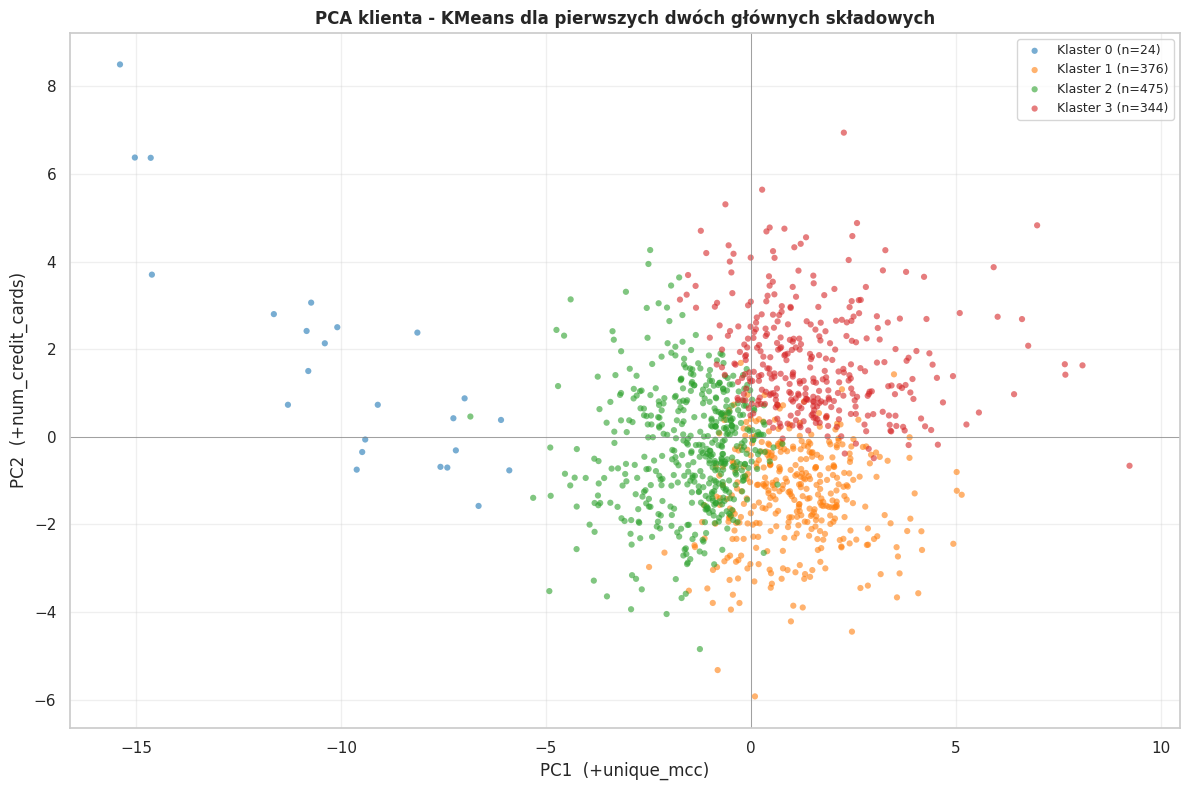

In [13]:
analysis.plot_graph(plot_pca_clusters, pca.scores, pca.clusters, pca.loadings)

## 7. Modele do wykrywania transakcji oszukańczych
Głównym wyzwaniem przy trenowaniu modeli było poradzenie sobie z bardzo mocno niezbalansowanym zbiorem danych.

In [ ]:
from transaction_analysis.models.features import build_features

X, y = build_features()

In [41]:
print(f"Transactions: {len(X):,}  |  Fraud: {y.sum():,} |  Fraud rate: {y.mean():.4%}")

Transactions: 13,305,915  |  Fraud: 13,332 |  Fraud rate: 0.1002%


Oprócz standardowego zbioru, metoda build_features przygotowuje zestaw cech, które mają wspomóc działanie modeli.

In [43]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 47 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount_usd             float32
 1   transaction_type       int8   
 2   mcc                    int8   
 3   amount_mean            float32
 4   amount_median          float32
 5   amount_std             float32
 6   amount_min             float32
 7   amount_max             float32
 8   txn_span_days          int16  
 9   txn_frequency          float16
 10  unique_merchants       int16  
 11  error_rate_pct         float16
 12  chip_usage_pct         float16
 13  gender                 int8   
 14  credit_score           int16  
 15  per_capita_income_usd  float32
 16  yearly_income_usd      float32
 17  total_debt_usd         float32
 18  num_credit_cards       uint8  
 19  num_cards              int8   
 20  avg_credit_limit       float32
 21  inter_txn_hours_mean   float16
 22  inter_txn_hours_std    floa

Jako bazowy model zaimplementowano Random Forest. Dodatkowo zaimplementowano XGBoost - model zespołowy, którego uczenie jest wzmocnione poprzez metody gradientowe, aby zbadać czy istnieje istotna statystycznie różnica pomiędzy predykcjami.

In [45]:
from sklearn.utils import resample

from transaction_analysis.models.config import CrossValidationConfig, RFConfig, XGBConfig
from transaction_analysis.models.factory import ModelType, cross_validate_model

X_cv, y_cv = resample(X, y, n_samples=1_000_000, stratify=y, random_state=42)

xgb_results = cross_validate_model(
    ModelType.XGB, XGBConfig(max_depth=5), CrossValidationConfig(), X_cv.values, y_cv.values
)

rf_results = cross_validate_model(
    ModelType.RF, RFConfig(max_depth=5), CrossValidationConfig(), X_cv.values, y_cv.values
)

CV XGB:   0%|          | 0/5 [00:00<?, ?fold/s]/home/robert/TAI/DataAnalysis/lab1/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [10:11:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_threads", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
CV XGB:  20%|██        | 1/5 [00:47<03:09, 47.27s/fold, fold=1]/home/robert/TAI/DataAnalysis/lab1/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [10:12:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_threads", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
CV XGB:  40%|████      | 2/5 [01:48<02:46, 55.38s/fold, fold=2]/home/robert/TAI/DataAnalysis/lab1/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [10:13:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_threads", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
CV XGB:  60%|██████    

Raport z treningu obu modeli:

In [46]:
from transaction_analysis.models.evaluate import print_report, summarise_cv

print(summarise_cv(xgb_results).to_string())
print_report(xgb_results, ModelType.XGB)
print(summarise_cv(rf_results).to_string())
print_report(rf_results, ModelType.RF)

       roc_auc  avg_precision
0     0.952714       0.261665
1     0.947462       0.260291
2     0.949663       0.255837
3     0.967678       0.236861
4     0.947911       0.233290
mean  0.953085       0.249589
std   0.008414       0.013482
       roc_auc  avg_precision
0     0.860304       0.018304
1     0.888070       0.030310
2     0.868401       0.014734
3     0.898307       0.021487
4     0.861934       0.027213
mean  0.875403       0.022409
std   0.016908       0.006366


XGBoost uzyskał średni wynik ROC-AUC równy 0.953 ± 0.008, znacząco przewyższając Random Forest (0.875 ± 0.017). Jeszcze większe różnice zaobserwowano dla Average Precision, gdzie XGBoost osiągnął wartość 0.250, podczas gdy Random Forest jedynie 0.022. Wyniki te wskazują, że XGBoost znacznie skuteczniej identyfikuje transakcje oszukańcze, co jest szczególnie istotne w warunkach silnej nierównowagi klas charakterystycznej dla problemów fraud detection.

Następnie przeprowadzono testy statystyczne pomiędzy wynikami modeli. Do tego celu zastosowano test Wilcoxona oraz McNemara.

In [47]:
from transaction_analysis.models.compare import compare_models

print(compare_models(xgb_results, rf_results).to_string())

                    test   metric    statistic  p_value
0     Wilcoxon (ROC-AUC)  roc_auc       0.0000   0.0625
1  McNemar (predictions)      NaN  127234.4872   0.0000


XGBoost osiągał wyższe wartości ROC-AUC we wszystkich 5 foldach walidacji krzyżowej. Test Wilcoxona wykazał istotność statystyczną na poziomie α = 0.05 (p = 0.0625), co zgadza się z obserwowaną przewagą, spójną we wszystkich podziałach danych.
Jednocześnie test McNemary wykazał istotne różnice w samych predykcjach modeli (p < 0.001), wskazując, że mimo podobnej jakości klasyfikacji mierzonej ROC-AUC, modele popełniają błędy na różnych obserwacjach.

## 7. Fairness study
Bazując na kolumnie "Płeć" zbadaliśmy czy modele wykazują bias, tzn. czy ta cecha wpływa na ocenę modeli w wykrywaniu oszukańczych transakcji.

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [56]:
print(f"Shape: {X.shape}")
print(f"Fraud rate: {y.mean():.4f}")
print(f"\nGender stats:\n{X['gender'].value_counts()}")

Shape: (13305915, 47)
Fraud rate: 0.0010

Gender stats:
gender
0    6815916
1    6489999
Name: count, dtype: int64


In [57]:
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=50000, replace=False)

X_sampled = X.iloc[sample_idx].reset_index(drop=True)
y_sampled = y.iloc[sample_idx].reset_index(drop=True)

# Pull gender out as the protected attribute and drop it from the model features
# so the classifier cannot use it directly.
gender_sampled = X_sampled["gender"].astype(int)
X_features = X_sampled.drop("gender", axis=1)

# Stratify on the fraud label so the rare positive class appears in both folds.
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_features, y_sampled, gender_sampled, test_size=0.3, random_state=42, stratify=y_sampled
)

print(f"Sample: {X_sampled.shape} | gender counts: {dict(gender_sampled.value_counts())}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Sample: (50000, 47) | gender counts: {0: np.int64(25635), 1: np.int64(24365)}
Train: (35000, 46) | Test: (15000, 46)


Próbnie wytrenowany model Random Forest

In [58]:
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate only top ALERT_RATE percent of transactions by model
ALERT_RATE = 0.05
threshold = np.quantile(y_pred_proba, 1 - ALERT_RATE)
y_pred = (y_pred_proba >= threshold).astype(int)

recall = y_pred[y_test.values == 1].mean()
print(f"Alert rate: {ALERT_RATE:.0%} | threshold: {threshold:.4f} | flagged: {int(y_pred.sum())}")
print(f"Accuracy: {(y_pred == y_test).mean():.4f} | Fraud recall @ budget: {recall:.4f}")

Alert rate: 5% | threshold: 0.0972 | flagged: 750
Accuracy: 0.9495 | Fraud recall @ budget: 0.1818


In [59]:
# Create aif360 datasets for fairness analysis
test_df_gender = pd.DataFrame({"true": y_test.values, "gender": gender_test.values})

dataset_gender_true = BinaryLabelDataset(
    df=test_df_gender,
    label_names=["true"],
    protected_attribute_names=["gender"],
    favorable_label=1,
    unfavorable_label=0,
)

dataset_gender_pred = dataset_gender_true.copy()
dataset_gender_pred.labels = y_pred.reshape(-1, 1)

print("Datasets (ground truth + predictions) created for fairness analysis")

Datasets (ground truth + predictions) created for fairness analysis


Badanie Fairness360

In [60]:
metrics_gender = ClassificationMetric(
    dataset_gender_true,
    dataset_gender_pred,
    unprivileged_groups=[{"gender": 0}],
    privileged_groups=[{"gender": 1}],
)

fairness_gender = {
    "Disparate Impact": metrics_gender.disparate_impact(),
    "Statistical Parity Difference": metrics_gender.statistical_parity_difference(),
    "Equal Opportunity Difference": metrics_gender.equal_opportunity_difference(),
    "Theil Index": metrics_gender.theil_index(),
}

print("=== FAIRNESS METRICS BY GENDER ===")
for metric, value in fairness_gender.items():
    print(f"{metric}: {value:.4f}")

print("\n[Notes]")
print("Disparate Impact ~1.0 = fair | <0.8 or >1.25 = potential bias")
print("Statistical Parity Difference ~0 = fair")
print("Equal Opportunity Difference ~0 = fair")

=== FAIRNESS METRICS BY GENDER ===
Disparate Impact: 0.9323
Statistical Parity Difference: -0.0035
Equal Opportunity Difference: 0.0333
Theil Index: 0.0178

[Notes]
Disparate Impact ~1.0 = fair | <0.8 or >1.25 = potential bias
Statistical Parity Difference ~0 = fair
Equal Opportunity Difference ~0 = fair


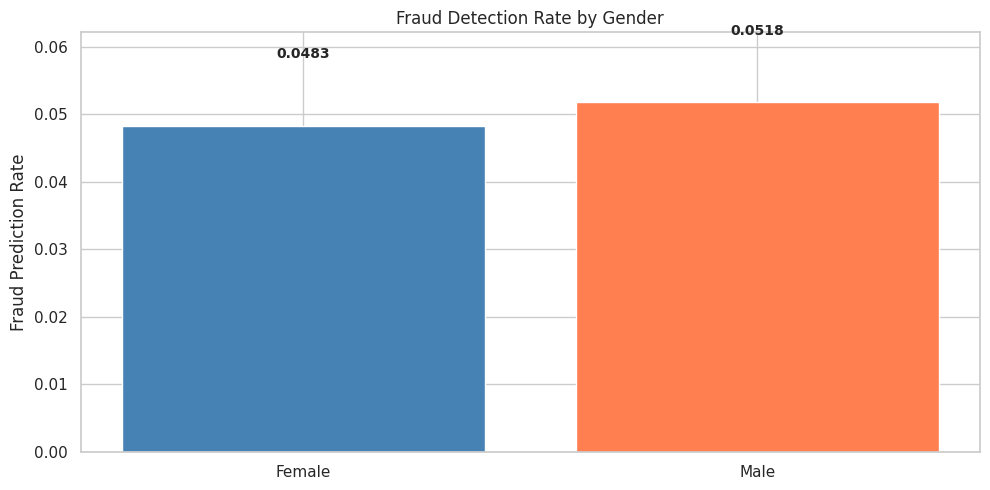

Prediction rate difference (Gender): 0.0035


In [62]:
from transaction_analysis.config.paths import PLOTS_DIR

# Compare prediction rates across groups
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# By Gender (LabelEncoder: Female=0, Male=1)
gender_names = {0: "Female", 1: "Male"}
pred_rate_gender = [y_pred[gender_test == g].mean() for g in [0, 1]]
ax.bar(list(gender_names.values()), pred_rate_gender, color=["steelblue", "coral"])
ax.set_ylabel("Fraud Prediction Rate")
ax.set_title("Fraud Detection Rate by Gender")
ax.set_ylim([0, max(pred_rate_gender) * 1.2])
for i, v in enumerate(pred_rate_gender):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fairness_prediction_rates.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Prediction rate difference (Gender): {abs(pred_rate_gender[0] - pred_rate_gender[1]):.4f}")

In [63]:
# Summary
print("=" * 60)
print("FAIRNESS STUDY SUMMARY")
print("=" * 60)

# Gender fairness assessment
di_gender = fairness_gender["Disparate Impact"]
if np.isnan(di_gender):
    # Undefined when the privileged group has no predicted-positive cases
    gender_status = "UNDEFINED (too few positive predictions)"
elif 0.8 <= di_gender <= 1.25:
    gender_status = "FAIR"
else:
    gender_status = "BIASED"

print(f"\nGender Fairness: {gender_status}")
print(f"  - Disparate Impact: {di_gender:.4f}")
print(f"  - Fraud flag rate: Female {pred_rate_gender[0]:.4f} vs Male {pred_rate_gender[1]:.4f}")

print("\n" + "=" * 60)

FAIRNESS STUDY SUMMARY

Gender Fairness: FAIR
  - Disparate Impact: 0.9323
  - Fraud flag rate: Female 0.0483 vs Male 0.0518



Podczas predykcji oszustw model nie jest uprzedzony do płci osoby wykonującej transakcje.

## 8. Dryfowanie zbioru danych

In [ ]:
from scipy import stats

from transaction_analysis.data.loader import load_all_transactions, load_users

transactions = load_all_transactions()
users = load_users()

columns_transaction = ["amount_usd", "transaction_type", "mcc", "fraud"]
columns_users = [
    "birth_date",
    "gender",
    "per_capita_income_usd",
    "yearly_income_usd",
    "total_debt_usd",
    "credit_score",
    "num_credit_cards",
]

categorical_transaction = ["transaction_type", "mcc", "fraud"]
categorical_users = ["gender"]

transactions_old, transactions_new = (
    transactions[transactions["date"] < "2015-01-01"],
    transactions[transactions["date"] >= "2015-01-01"],
)
users_old, users_new = users[users["id"] < 1000], users[users["id"] >= 1000]
del transactions, users

In [16]:
transactions_new.head()

,transaction_id,date,client_id,card_id,amount_usd,transaction_type,merchant_id,merchant_city,merchant_state,zip,mcc,errors,fraud
6571667,15471192,2015-01-01 00:01:00,316,2038,69.550003,Chip Transaction,79360,Giddings,TX,78942,5411,NaN,<NA>
6571668,15471193,2015-01-01 00:01:00,1585,339,34.820000,Swipe Transaction,69972,Jacksonville,FL,32222,5814,NaN,False
6571669,15471194,2015-01-01 00:03:00,848,3915,64.400002,Chip Transaction,13051,Harwood,MD,20776,5813,NaN,False
6571670,15471195,2015-01-01 00:04:00,1797,300,47.930000,Chip Transaction,54343,San Leandro,CA,94577,4121,NaN,False
6571671,15471196,2015-01-01 00:05:00,1557,2471,25.750000,Online Transaction,9932,ONLINE,NaN,NaN,5311,NaN,False


In [17]:
def columns_drift(
    dataframe_old: pd.DataFrame,
    dataframe_new: pd.DataFrame,
    columns: list[str],
    categorical_columns: list[str] | None = None,
) -> pd.DataFrame:
    categorical_columns = categorical_columns or []
    results = []
    for column in columns:
        ks_shift = stats.ks_2samp(dataframe_old[column].dropna(), dataframe_new[column].dropna())

        chi2_stat, chi2_pvalue = pd.NA, pd.NA
        if column in categorical_columns:
            contingency = (
                pd.DataFrame(
                    {
                        "old": dataframe_old[column].dropna().value_counts(),
                        "new": dataframe_new[column].dropna().value_counts(),
                    }
                )
                .fillna(0)
                .astype(float)
            )
            chi2_shift = stats.chi2_contingency(contingency)
            chi2_stat, chi2_pvalue = chi2_shift.statistic, chi2_shift.pvalue

        results.append(
            {
                "column": column,
                "ks_stat": ks_shift.statistic,
                "ks_pvalue": ks_shift.pvalue,
                "chi2_stat": chi2_stat,
                "chi2_pvalue": chi2_pvalue,
            }
        )

    return pd.DataFrame(results)


columns_drift(transactions_old, transactions_new, columns_transaction, categorical_transaction)

,column,ks_stat,ks_pvalue,chi2_stat,chi2_pvalue
0,amount_usd,0.005323,2.713139e-82,<NA>,<NA>
1,transaction_type,0.718690,0.000000e+00,7948464.656272,0.0
2,mcc,0.007106,2.641449e-146,3768.561136,0.0
3,fraud,0.000471,7.052317e-01,331.112967,0.0


Silny drift jest tylko w `transaction_type`. W `amount_usd` i `mcc` rozbieżność jest znikoma - wysoka statystyka chi-kwadrat dla `mcc` wynika z dużej liczby kategorii (więcej stopni swobody), a nie z faktycznego dryfu, dlatego surowej statystyki nie porównujemy między kolumnami.

W `fraud` statystyka jest niska, ale udział oszustw rośnie z 0.13% do 0.17% (~37% względnie) - to istotny dryf targetu.

Kolumny kategoryczne (`transaction_type`, `mcc`, `fraud`) mierzymy testem chi-kwadrat, bo nie mają porządku.

In [18]:
columns_drift(users_old, users_new, columns_users, categorical_users)

/mnt/shared/courses/1/analiza-danych/TransactionDatasetAnalysis/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,column,ks_stat,ks_pvalue,chi2_stat,chi2_pvalue
0,birth_date,0.017,0.998723,<NA>,<NA>
1,gender,0.002,1.000000,0.002001,0.964325
2,per_capita_income_usd,0.081,0.002818,<NA>,<NA>
3,yearly_income_usd,0.055,0.097103,<NA>,<NA>
4,total_debt_usd,0.065,0.029225,<NA>,<NA>
5,credit_score,0.030,0.759370,<NA>,<NA>
6,num_credit_cards,0.034,0.610166,<NA>,<NA>


Drift jest tylko w `per_capita_income_usd` oraz `total_debt_usd`; `yearly_income_usd` jest na granicy

## 9. Podsumowanie - najważniejsze wnioski

Przeprowadzona analiza pozwoliła przejść pełną ścieżkę od surowego, rozproszonego zbioru aż do wytrenowanych i przebadanych modeli wykrywających oszustwa.

**Preprocessing i optymalizacja**

Dobór właściwych typów danych pozwolił ograniczyć zużycie RAM o **75%** (1800 MB -> 432 MB), a zapis do `.parquet` zmniejszył rozmiar na dysku o **78%** (1200 MB -> 259 MB). Dzięki temu praca z dużym zbiorem stała się komfortowa.

**EDA - profilowanie oszustw**

Pierwsze wrażenie często myli: kanał `Online` czy popularne branże *wydają się* siedliskiem oszustw, ale dopiero **udział procentowy** względem wszystkich transakcji pokazuje prawdziwy obraz.

Najmocniejszy wzorzec to **brak powtarzalnych interakcji** - prawie każda oszukańcza transakcja trafia do nowego sprzedawcy. To typowy ślad  ataków automatycznych.

Oszustwa mają też wyraźnie inny rozkład liczby transakcji oraz sumy kwot niż transakcje legalne.

**Modele**

Głównym wyzwaniem był silnie niezbalansowany zbiór. `XGBoost` wyraźnie przewyższył `Random Forest`: ROC-AUC **0.953** vs **0.875**, a różnica w Average Precision była jeszcze większa (**0.250** vs **0.022**).

Test Wilcoxona nie wykazał istotności statystycznej (p = 0.0625), co wynika z małej liczby foldów, jednak przewaga `XGBoost` była spójna we wszystkich podziałach. Test McNemara potwierdził, że modele popełniają błędy na różnych obserwacjach (p < 0.001).

**Fairness**

Badanie z wykorzystaniem AIF360 wykazało, że model **nie jest uprzedzony względem płci** osoby wykonującej transakcję.

**Dryf danych**

Wzorcowy drift występuje w `transaction_type` oraz `fraud`; dla `amount_usd` i `mcc` rozbieżność jest niewielka mimo dużej liczby danych. W cechach demograficznych drift dotyczy `per_capita_income_usd` oraz `total_debt_usd`, a `yearly_income_usd` jest na granicy - to sygnał, że modele warto monitorować i okresowo dotrenowywać.
